# 🎮 e스포츠 vs 전통 스포츠: 대중적 관심도 종합 분석

---

## 📋 프로젝트 개요

| 항목 | 내용 |
|------|------|
| **대주제** | e스포츠도 스포츠인가? |
| **소주제** | e스포츠의 대중적 인기는 전통 스포츠에 필적하는가? |
| **분석 목표** | 데이터 기반 객관적 비교 분석 및 통계적 검증 |

---

## 🎯 분석 프레임워크

1. **탐색적 데이터 분석 (EDA)**: 데이터 구조 및 분포 파악
2. **기술통계 분석**: 중심경향, 산포도, 분포 특성
3. **상관관계 분석**: 변수 간 관계 파악
4. **회귀분석**: 성장 예측 모델링
5. **가설검정**: e스포츠 성장률 vs 전통 스포츠 성장률
6. **시계열 분석**: 트렌드 및 계절성 분석
7. **다양한 시각화**: 20+ 차트 유형 활용
8. **종합 평가**: 대중성 지수 산출

---

## 1️⃣ 라이브러리 및 환경 설정

In [1]:
# ============================================
# 필수 라이브러리 설치 (필요시 실행)
# ============================================
# !pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn
# !pip install plotly kaleido wordcloud squarify pytrends

In [2]:
# ============================================
# 라이브러리 임포트
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import platform
import os

# 통계 분석
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway, shapiro, normaltest
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 머신러닝 (예측)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

# 고급 시각화
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 기타
try:
    import squarify  # 트리맵
except:
    pass

# 경고 메시지 숨김
warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Pandas 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# 출력 디렉토리 생성
OUTPUT_DIR = 'output_final'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ 라이브러리 로드 완료!')
print(f'📂 출력 디렉토리: {OUTPUT_DIR}')

✅ 라이브러리 로드 완료!
📂 출력 디렉토리: output_final


In [3]:
# ============================================
# 컬러 팔레트 및 스타일 정의
# ============================================
COLORS = {
    # 카테고리별
    'esports': '#9B59B6',
    'traditional': '#27AE60',
    'highlight': '#E74C3C',
    'neutral': '#3498DB',
    
    # 게임별
    'League of Legends': '#C9AA71',
    'Counter-Strike: Global Offensive': '#DE9B35',
    'Dota 2': '#F44336',
    'Valorant': '#FD4556',
    'Fortnite': '#9D4DBB',
    'Just Chatting': '#6441A5',
    'Grand Theft Auto V': '#8BC34A',
    'Minecraft': '#7CB342',
    'PUBG: BATTLEGROUNDS': '#F2A900',
    'Apex Legends': '#DA292A',
    
    # 언어별
    'English': '#3498DB',
    'Korean': '#E74C3C',
    'Spanish': '#F1C40F',
    'Portuguese': '#2ECC71',
    'Russian': '#9B59B6',
    'Japanese': '#E91E63',
    'Chinese': '#FF5722',
    'German': '#607D8B',
    'French': '#00BCD4',
    'Other': '#95A5A6'
}

# 유틸리티 함수
def format_number(value):
    """큰 숫자를 읽기 쉬운 형식으로 변환"""
    if pd.isna(value):
        return 'N/A'
    if value >= 1e9:
        return f"{value/1e9:.2f}B"
    elif value >= 1e6:
        return f"{value/1e6:.2f}M"
    elif value >= 1e3:
        return f"{value/1e3:.2f}K"
    else:
        return f"{value:.0f}"

print('✅ 스타일 설정 완료!')

✅ 스타일 설정 완료!


---

## 2️⃣ 데이터 로드 및 전처리

In [4]:
# ============================================
# 데이터 경로 설정
# ============================================
DATA_PATH = 'data/'

# 인코딩 자동 감지 함수
def read_csv_auto_encoding(filepath, encodings=['utf-8', 'utf-8-sig', 'cp949', 'euc-kr', 'latin-1']):
    """여러 인코딩을 시도하여 CSV 파일을 읽음"""
    for encoding in encodings:
        try:
            df = pd.read_csv(filepath, encoding=encoding)
            print(f"  (인코딩: {encoding})")
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            # 인코딩 외의 오류는 마지막 인코딩으로 시도
            continue
    # 모든 인코딩 실패 시 latin-1로 강제 읽기 (바이트 손실 없음)
    return pd.read_csv(filepath, encoding='latin-1')

# 1. Twitch 채널 데이터
print("Loading: twitchdata-update.csv", end='')
twitch_channels = read_csv_auto_encoding(f'{DATA_PATH}twitchdata-update.csv')
print(f"✅ Twitch 채널 데이터: {twitch_channels.shape}")

# 2. Twitch 게임별 데이터 (2016-2023)
print("Loading: Twitch_game_data.csv", end='')
twitch_games = read_csv_auto_encoding(f'{DATA_PATH}Top games on Twitch 2016 - 2023/Twitch_game_data.csv')
print(f"✅ Twitch 게임 데이터: {twitch_games.shape}")

# 3. Twitch 글로벌 데이터
print("Loading: Twitch_global_data.csv", end='')
twitch_global = read_csv_auto_encoding(f'{DATA_PATH}Top games on Twitch 2016 - 2023/Twitch_global_data.csv')
print(f"✅ Twitch 글로벌 데이터: {twitch_global.shape}")

# 4. 글로벌 게이밍/e스포츠 데이터
print("Loading: global_gaming_esports_2010_2025.csv", end='')
global_esports = read_csv_auto_encoding(f'{DATA_PATH}global_gaming_esports_2010_2025.csv')
print(f"✅ 글로벌 e스포츠 데이터: {global_esports.shape}")

# 5. e스포츠 상금 데이터
print("Loading: GeneralEsportData.csv", end='')
esports_general = read_csv_auto_encoding(f'{DATA_PATH}Esports Earnings 1998 - 2023/GeneralEsportData.csv')
print(f"✅ e스포츠 일반 데이터: {esports_general.shape}")

# 6. e스포츠 역사적 데이터
print("Loading: HistoricalEsportData.csv", end='')
esports_historical = read_csv_auto_encoding(f'{DATA_PATH}Esports Earnings 1998 - 2023/HistoricalEsportData.csv')
print(f"✅ e스포츠 역사 데이터: {esports_historical.shape}")

# 7. 게이밍 산업 트렌드
print("Loading: gaming_industry_trends.csv", end='')
gaming_trends = read_csv_auto_encoding(f'{DATA_PATH}gaming_industry_trends.csv')
print(f"✅ 게이밍 트렌드 데이터: {gaming_trends.shape}")

print("\n🎉 모든 데이터 로드 완료!")

Loading: twitchdata-update.csv  (인코딩: utf-8)
✅ Twitch 채널 데이터: (1000, 11)
Loading: Twitch_game_data.csv  (인코딩: latin-1)
✅ Twitch 게임 데이터: (21000, 12)
Loading: Twitch_global_data.csv  (인코딩: utf-8)
✅ Twitch 글로벌 데이터: (105, 9)
Loading: global_gaming_esports_2010_2025.csv  (인코딩: utf-8)
✅ 글로벌 e스포츠 데이터: (400, 21)
Loading: GeneralEsportData.csv  (인코딩: utf-8)
✅ e스포츠 일반 데이터: (669, 8)
Loading: HistoricalEsportData.csv  (인코딩: utf-8)
✅ e스포츠 역사 데이터: (10239, 5)
Loading: gaming_industry_trends.csv  (인코딩: utf-8)
✅ 게이밍 트렌드 데이터: (1000, 11)

🎉 모든 데이터 로드 완료!


In [5]:
# ============================================
# 데이터 전처리
# ============================================

# 1. Twitch 채널 데이터 전처리
twitch_channels = twitch_channels.rename(columns={
    'Watch time(Minutes)': 'Watch_time_minutes',
    'Stream time(minutes)': 'Stream_time_minutes',
    'Peak viewers': 'Peak_viewers',
    'Average viewers': 'Avg_viewers',
    'Followers gained': 'Followers_gained',
    'Views gained': 'Views_gained'
})
twitch_channels['Watch_time_hours'] = twitch_channels['Watch_time_minutes'] / 60
twitch_channels['Stream_time_hours'] = twitch_channels['Stream_time_minutes'] / 60
twitch_channels['Efficiency'] = twitch_channels['Watch_time_hours'] / twitch_channels['Stream_time_hours'].replace(0, np.nan)

# 2. Twitch 게임 데이터 전처리
twitch_games['Date'] = pd.to_datetime(
    twitch_games['Year'].astype(str) + '-' + twitch_games['Month'].astype(str).str.zfill(2) + '-01'
)

# 3. Twitch 글로벌 데이터 전처리
twitch_global = twitch_global.rename(columns={'year': 'Year'})
twitch_global['Date'] = pd.to_datetime(
    twitch_global['Year'].astype(str) + '-' + twitch_global['Month'].astype(str).str.zfill(2) + '-01'
)

# 4. e스포츠 역사 데이터 전처리
esports_historical['Date'] = pd.to_datetime(esports_historical['Date'])
esports_historical['Year'] = esports_historical['Date'].dt.year
esports_historical['Month'] = esports_historical['Date'].dt.month

print('✅ 데이터 전처리 완료!')

✅ 데이터 전처리 완료!


In [6]:
# ============================================
# 전통 스포츠 비교 데이터 (공식 통계 기반)
# ============================================

# 주요 스포츠 이벤트 시청자 데이터
traditional_sports = pd.DataFrame({
    'Event': [
        'FIFA 월드컵 결승 (2022)', 'UEFA 챔피언스리그 결승', '슈퍼볼 LVIII (2024)',
        'NBA 파이널 (2023)', 'ICC 크리켓 월드컵 결승', '윔블던 결승',
        'LoL Worlds 결승 (2023)', 'Dota 2 TI 결승', 'Valorant Champions',
        'CS2 Major 결승', 'Fortnite World Cup'
    ],
    'Peak_Viewers_Million': [1500, 450, 123.4, 13, 300, 10, 6.4, 1.7, 1.5, 1.8, 2.3],
    'Category': ['전통', '전통', '전통', '전통', '전통', '전통', 
                 'e스포츠', 'e스포츠', 'e스포츠', 'e스포츠', 'e스포츠'],
    'Sport_Type': ['축구', '축구', '미식축구', '농구', '크리켓', '테니스',
                   'LoL', 'Dota2', 'Valorant', 'CS2', 'Fortnite'],
    'Year': [2022, 2023, 2024, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2019]
})

# 시장 규모 비교 데이터 (십억 USD)
market_comparison = pd.DataFrame({
    'Industry': ['글로벌 스포츠 산업', 'NFL', 'EPL', 'NBA', 'MLB', 
                 '글로벌 e스포츠', 'LoL e스포츠', 'Dota 2 e스포츠'],
    'Market_Size_Billion': [500, 18.6, 6.4, 10.5, 11.0, 1.87, 0.35, 0.25],
    'Growth_Rate': [5.2, 3.8, 4.5, 4.2, 2.1, 15.3, 12.8, 8.5],
    'Category': ['전통', '전통', '전통', '전통', '전통', 'e스포츠', 'e스포츠', 'e스포츠']
})

# 인구통계학적 데이터
demographic_data = pd.DataFrame({
    'Age_Group': ['13-17세', '18-24세', '25-34세', '35-44세', '45-54세', '55세 이상'],
    'Esports_Interest': [72, 68, 52, 31, 15, 8],
    'Traditional_Interest': [45, 55, 62, 68, 71, 74],
    'Population_Share': [7, 12, 18, 17, 16, 30]
})

print('✅ 비교 데이터 생성 완료!')
display(traditional_sports)

✅ 비교 데이터 생성 완료!


,Event,Peak_Viewers_Million,Category,Sport_Type,Year
0,FIFA 월드컵 결승 (2022),"1,500.00",전통,축구,2022
1,UEFA 챔피언스리그 결승,450.00,전통,축구,2023
2,슈퍼볼 LVIII (2024),123.40,전통,미식축구,2024
3,NBA 파이널 (2023),13.00,전통,농구,2023
4,ICC 크리켓 월드컵 결승,300.00,전통,크리켓,2023
5,윔블던 결승,10.00,전통,테니스,2023
6,LoL Worlds 결승 (2023),6.40,e스포츠,LoL,2023
7,Dota 2 TI 결승,1.70,e스포츠,Dota2,2023
8,Valorant Champions,1.50,e스포츠,Valorant,2023
9,CS2 Major 결승,1.80,e스포츠,CS2,2023


---

## 3️⃣ 탐색적 데이터 분석 (EDA)

In [7]:
# ============================================
# 3.1 데이터 구조 확인
# ============================================
print('='*70)
print('📊 Twitch 채널 데이터 구조')
print('='*70)
print(f'Shape: {twitch_channels.shape}')
print(f'\n컬럼: {twitch_channels.columns.tolist()}')
print(f'\n데이터 타입:')
print(twitch_channels.dtypes)
print(f'\n결측치:')
print(twitch_channels.isnull().sum())

📊 Twitch 채널 데이터 구조
Shape: (1000, 14)

컬럼: ['Channel', 'Watch_time_minutes', 'Stream_time_minutes', 'Peak_viewers', 'Avg_viewers', 'Followers', 'Followers_gained', 'Views_gained', 'Partnered', 'Mature', 'Language', 'Watch_time_hours', 'Stream_time_hours', 'Efficiency']

데이터 타입:
Channel                 object
Watch_time_minutes       int64
Stream_time_minutes      int64
Peak_viewers             int64
Avg_viewers              int64
Followers                int64
Followers_gained         int64
Views_gained             int64
Partnered                 bool
Mature                    bool
Language                object
Watch_time_hours       float64
Stream_time_hours      float64
Efficiency             float64
dtype: object

결측치:
Channel                0
Watch_time_minutes     0
Stream_time_minutes    0
Peak_viewers           0
Avg_viewers            0
Followers              0
Followers_gained       0
Views_gained           0
Partnered              0
Mature                 0
Language          

In [8]:
# ============================================
# 3.2 기술통계량
# ============================================
print('='*70)
print('📊 Twitch 채널 데이터 기술통계')
print('='*70)

desc_stats = twitch_channels[['Watch_time_hours', 'Stream_time_hours', 'Peak_viewers', 
                              'Avg_viewers', 'Followers', 'Efficiency']].describe()
display(desc_stats)

# 추가 통계량
print('\n📈 추가 통계량:')
for col in ['Watch_time_hours', 'Followers', 'Avg_viewers']:
    data = twitch_channels[col].dropna()
    print(f'\n{col}:')
    print(f'  - 왜도(Skewness): {stats.skew(data):.4f}')
    print(f'  - 첨도(Kurtosis): {stats.kurtosis(data):.4f}')
    print(f'  - 변동계수(CV): {data.std()/data.mean()*100:.2f}%')

📊 Twitch 채널 데이터 기술통계


,Watch_time_hours,Stream_time_hours,Peak_viewers,Avg_viewers,Followers,Efficiency
count,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00"
mean,"6,973,798.84","2,008.59","37,065.05","4,781.04","570,054.07","5,122.91"
std,"9,160,591.90","1,422.94","60,314.31","8,453.68","804,413.37","9,135.28"
min,"2,036,547.50",57.75,496.00,235.00,"3,660.00",236.42
25%,"2,719,831.56","1,229.31","9,113.75","1,457.75","170,546.25","1,519.62"
50%,"3,916,513.12","1,804.00","16,676.00","2,425.00","318,063.00","2,580.33"
75%,"7,228,998.62","2,364.06","37,569.75","4,786.25","624,332.25","5,029.55"
max,"103,269,362.50","8,690.75","639,375.00","147,643.00","8,938,903.00","161,136.60"



📈 추가 통계량:

Watch_time_hours:
  - 왜도(Skewness): 5.1581
  - 첨도(Kurtosis): 38.2352
  - 변동계수(CV): 131.36%

Followers:
  - 왜도(Skewness): 4.5431
  - 첨도(Kurtosis): 29.1719
  - 변동계수(CV): 141.11%

Avg_viewers:
  - 왜도(Skewness): 9.0530
  - 첨도(Kurtosis): 126.2031
  - 변동계수(CV): 176.82%


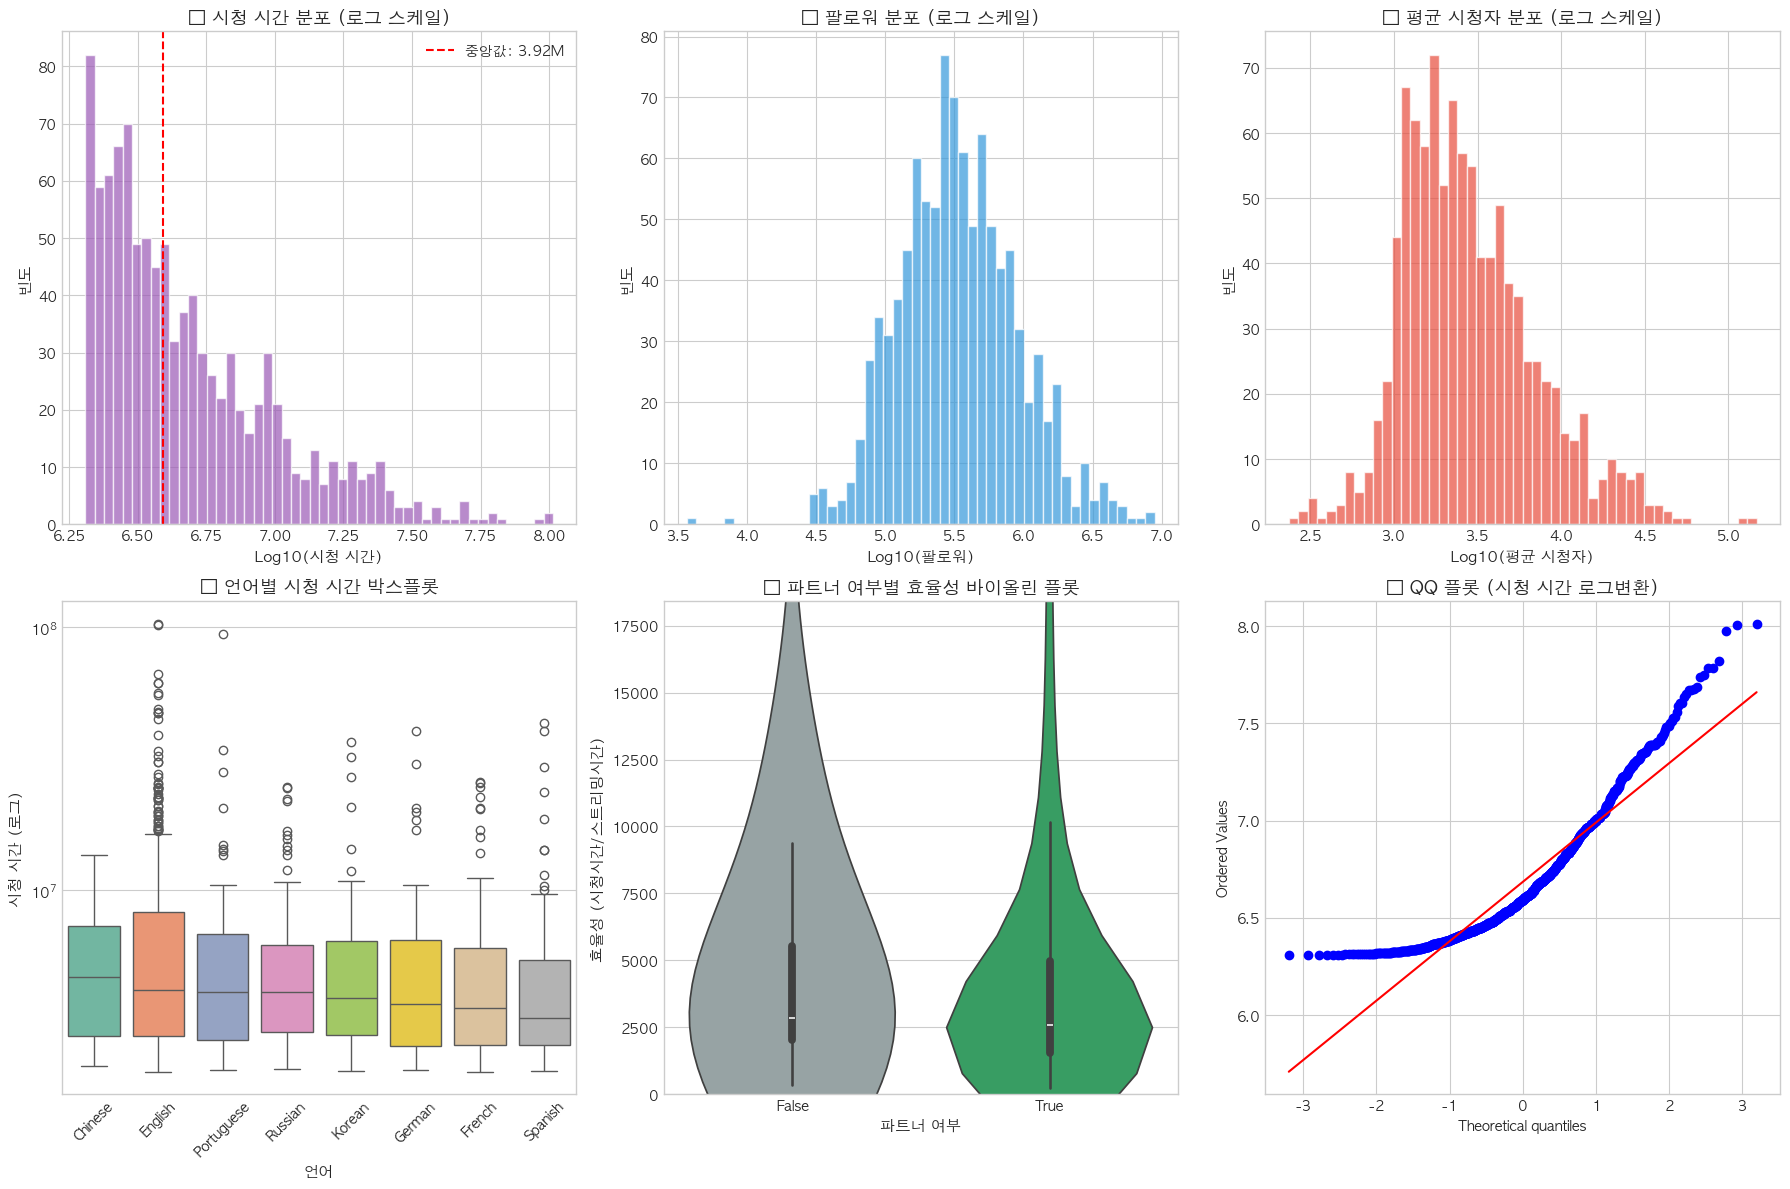

In [30]:
# ============================================
# 3.3 분포 시각화 (히스토그램, 박스플롯, 바이올린 플롯)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 시청 시간 분포 (로그 스케일)
axes[0, 0].hist(np.log10(twitch_channels['Watch_time_hours'].replace(0, np.nan).dropna()), 
                bins=50, color=COLORS['esports'], edgecolor='white', alpha=0.7)
axes[0, 0].set_xlabel('Log10(시청 시간)', fontsize=11)
axes[0, 0].set_ylabel('빈도', fontsize=11)
axes[0, 0].set_title('📊 시청 시간 분포 (로그 스케일)', fontsize=13, fontweight='bold')
axes[0, 0].axvline(np.log10(twitch_channels['Watch_time_hours'].median()), 
                   color='red', linestyle='--', label=f"중앙값: {format_number(twitch_channels['Watch_time_hours'].median())}")
axes[0, 0].legend()

# 팔로워 분포
axes[0, 1].hist(np.log10(twitch_channels['Followers'].replace(0, np.nan).dropna()), 
                bins=50, color=COLORS['neutral'], edgecolor='white', alpha=0.7)
axes[0, 1].set_xlabel('Log10(팔로워)', fontsize=11)
axes[0, 1].set_ylabel('빈도', fontsize=11)
axes[0, 1].set_title('📊 팔로워 분포 (로그 스케일)', fontsize=13, fontweight='bold')

# 평균 시청자 분포
axes[0, 2].hist(np.log10(twitch_channels['Avg_viewers'].replace(0, np.nan).dropna()), 
                bins=50, color=COLORS['highlight'], edgecolor='white', alpha=0.7)
axes[0, 2].set_xlabel('Log10(평균 시청자)', fontsize=11)
axes[0, 2].set_ylabel('빈도', fontsize=11)
axes[0, 2].set_title('📊 평균 시청자 분포 (로그 스케일)', fontsize=13, fontweight='bold')

# 박스플롯 - 언어별 시청 시간
top_langs = twitch_channels['Language'].value_counts().head(8).index
lang_data = twitch_channels[twitch_channels['Language'].isin(top_langs)]
lang_order = lang_data.groupby('Language')['Watch_time_hours'].median().sort_values(ascending=False).index
sns.boxplot(data=lang_data, x='Language', y='Watch_time_hours', order=lang_order, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('언어', fontsize=11)
axes[1, 0].set_ylabel('시청 시간 (로그)', fontsize=11)
axes[1, 0].set_title('📦 언어별 시청 시간 박스플롯', fontsize=13, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# 바이올린 플롯 - 파트너 여부별 효율성
sns.violinplot(data=twitch_channels, x='Partnered', y='Efficiency', ax=axes[1, 1], palette=['#95a5a6', '#27ae60'])
axes[1, 1].set_ylim(0, twitch_channels['Efficiency'].quantile(0.95))
axes[1, 1].set_xlabel('파트너 여부', fontsize=11)
axes[1, 1].set_ylabel('효율성 (시청시간/스트리밍시간)', fontsize=11)
axes[1, 1].set_title('🎻 파트너 여부별 효율성 바이올린 플롯', fontsize=13, fontweight='bold')

# QQ 플롯 - 정규성 검정
log_watch = np.log10(twitch_channels['Watch_time_hours'].replace(0, np.nan).dropna())
stats.probplot(log_watch, dist='norm', plot=axes[1, 2])
axes[1, 2].set_title('📈 QQ 플롯 (시청 시간 로그변환)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================
# 3.4 정규성 검정
# ============================================
print('='*70)
print('📊 정규성 검정 (Shapiro-Wilk & D\'Agostino)')
print('='*70)

test_vars = ['Watch_time_hours', 'Followers', 'Avg_viewers', 'Efficiency']

for var in test_vars:
    data = twitch_channels[var].dropna()
    # 샘플 크기가 크면 일부만 사용
    sample = data.sample(min(5000, len(data)), random_state=42)
    
    # 원본 데이터 검정
    stat_dag, p_dag = normaltest(sample)
    
    # 로그 변환 데이터 검정
    log_sample = np.log10(sample.replace(0, np.nan).dropna())
    if len(log_sample) > 20:
        stat_dag_log, p_dag_log = normaltest(log_sample)
    else:
        stat_dag_log, p_dag_log = np.nan, np.nan
    
    print(f'\n{var}:')
    print(f'  원본 - D\'Agostino p-value: {p_dag:.4e} {"(정규성 X)" if p_dag < 0.05 else "(정규성 O)"}')
    print(f'  로그변환 - D\'Agostino p-value: {p_dag_log:.4e} {"(정규성 X)" if p_dag_log < 0.05 else "(정규성 O)"}')

📊 정규성 검정 (Shapiro-Wilk & D'Agostino)

Watch_time_hours:
  원본 - D'Agostino p-value: 1.2760e-232 (정규성 X)
  로그변환 - D'Agostino p-value: 1.6556e-39 (정규성 X)

Followers:
  원본 - D'Agostino p-value: 4.4274e-211 (정규성 X)
  로그변환 - D'Agostino p-value: 3.1359e-03 (정규성 X)

Avg_viewers:
  원본 - D'Agostino p-value: 0.0000e+00 (정규성 X)
  로그변환 - D'Agostino p-value: 9.1331e-18 (정규성 X)

Efficiency:
  원본 - D'Agostino p-value: 0.0000e+00 (정규성 X)
  로그변환 - D'Agostino p-value: 2.3890e-18 (정규성 X)


---

## 4️⃣ 상관관계 분석

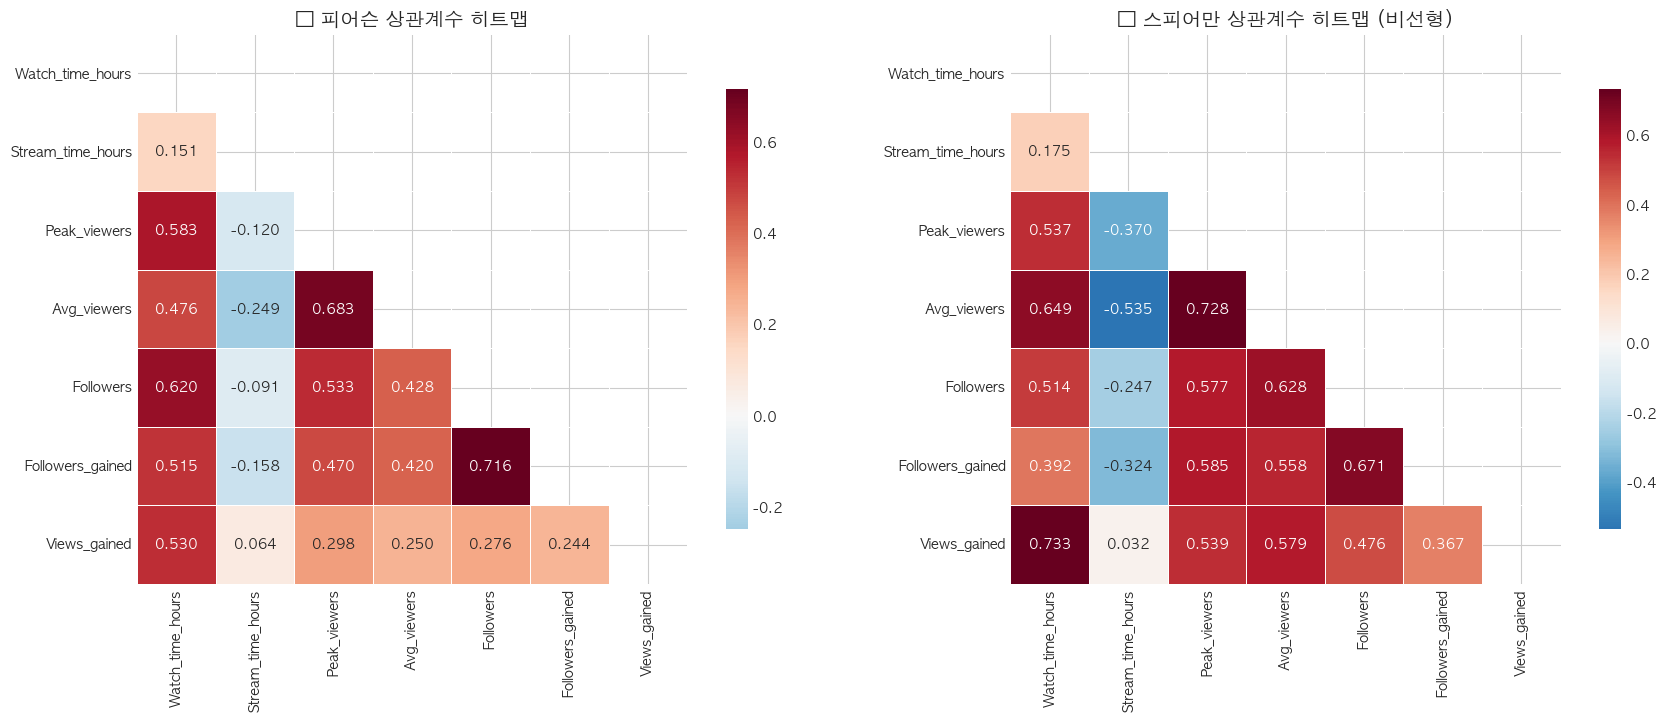


📊 주요 상관관계 통계적 유의성 검정:
  Watch_time_hours vs Followers: r=0.6202, p-value=2.3275e-107 ***
  Avg_viewers vs Peak_viewers: r=0.6826, p-value=4.1044e-138 ***
  Stream_time_hours vs Followers_gained: r=-0.1582, p-value=4.9814e-07 ***


In [31]:
# ============================================
# 4.1 피어슨 상관계수 분석
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

numeric_cols = ['Watch_time_hours', 'Stream_time_hours', 'Peak_viewers', 
                'Avg_viewers', 'Followers', 'Followers_gained', 'Views_gained']

# 상관계수 행렬
corr_matrix = twitch_channels[numeric_cols].corr(method='pearson')

# 히트맵
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 피어슨 상관계수
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, ax=axes[0], square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('🔥 피어슨 상관계수 히트맵', fontsize=14, fontweight='bold')

# 스피어만 상관계수 (비선형 관계)
corr_spearman = twitch_channels[numeric_cols].corr(method='spearman')
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, ax=axes[1], square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('🔥 스피어만 상관계수 히트맵 (비선형)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 통계적 유의성 검정
print('\n📊 주요 상관관계 통계적 유의성 검정:')
pairs = [('Watch_time_hours', 'Followers'), ('Avg_viewers', 'Peak_viewers'), 
         ('Stream_time_hours', 'Followers_gained')]
for x, y in pairs:
    data_clean = twitch_channels[[x, y]].dropna()
    r, p = pearsonr(data_clean[x], data_clean[y])
    print(f'  {x} vs {y}: r={r:.4f}, p-value={p:.4e} {"***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""}')

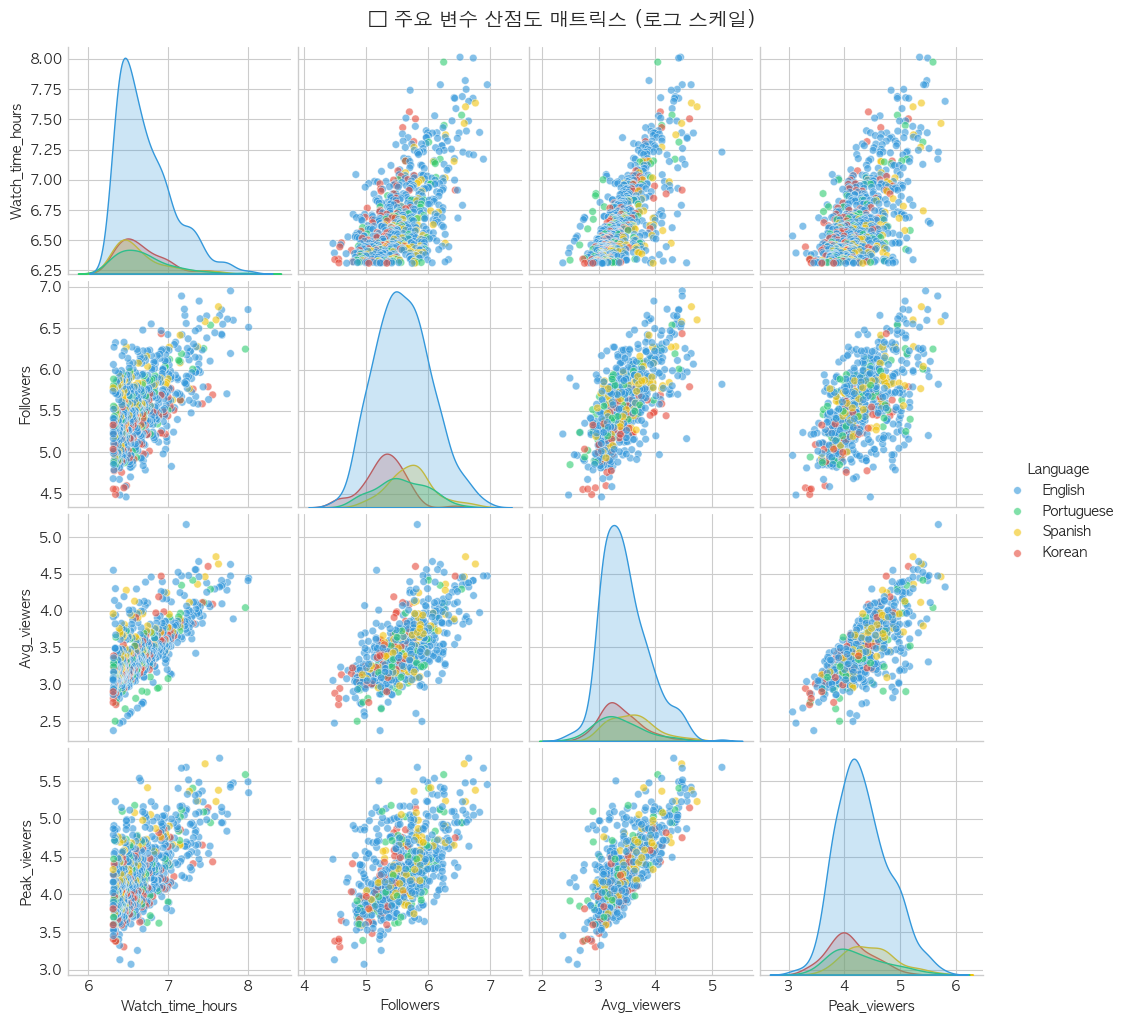

In [32]:
# ============================================
# 4.2 산점도 매트릭스 (Pair Plot)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 로그 변환된 데이터로 시각화
log_data = twitch_channels[['Watch_time_hours', 'Followers', 'Avg_viewers', 'Peak_viewers']].copy()
for col in log_data.columns:
    log_data[col] = np.log10(log_data[col].replace(0, np.nan))
log_data['Language'] = twitch_channels['Language']
log_data = log_data[log_data['Language'].isin(['English', 'Korean', 'Spanish', 'Portuguese'])]

g = sns.pairplot(log_data.dropna(), hue='Language', diag_kind='kde',
                 palette={'English': '#3498DB', 'Korean': '#E74C3C', 
                          'Spanish': '#F1C40F', 'Portuguese': '#2ECC71'},
                 plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('📊 주요 변수 산점도 매트릭스 (로그 스케일)', fontsize=14, fontweight='bold', y=1.02)
plt.savefig(f'{OUTPUT_DIR}/03_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 5️⃣ 회귀분석 및 예측

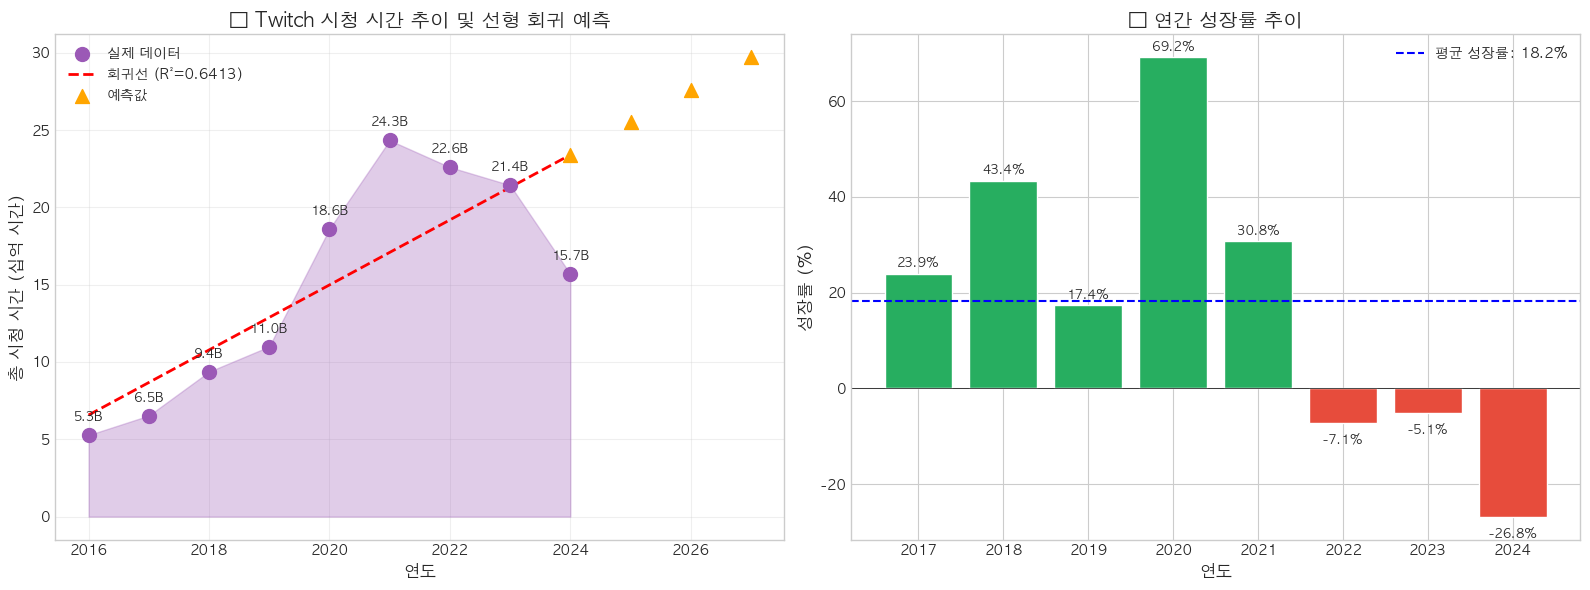


📊 선형 회귀 분석 결과:
  - 기울기(β): 2.1031 (연간 2.10B 시간 증가)
  - 절편(α): -4233.1947
  - R² Score: 0.6413
  - RMSE: 4.0615B

📈 미래 예측:
  - 2024년: 23.39B 시간
  - 2025년: 25.50B 시간
  - 2026년: 27.60B 시간
  - 2027년: 29.70B 시간


In [34]:
# ============================================
# 5.1 연도별 시청 시간 추이 및 선형 회귀
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

plt.rcParams['font.family'] = 'AppleGothic'  # Mac

yearly_stats = twitch_global.groupby('Year').agg({
    'Hours_watched': 'sum',
    'Avg_viewers': 'mean',
    'Peak_viewers': 'max'
}).reset_index()

# 성장률 계산
yearly_stats['Growth_Rate'] = yearly_stats['Hours_watched'].pct_change() * 100

# 선형 회귀
X = yearly_stats['Year'].values.reshape(-1, 1)
y = yearly_stats['Hours_watched'].values / 1e9  # 십억 단위

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# 미래 예측 (2024-2027)
future_years = np.array([2024, 2025, 2026, 2027]).reshape(-1, 1)
future_pred = model.predict(future_years)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 시청 시간 추이 + 회귀선
axes[0].scatter(yearly_stats['Year'], y, s=100, color=COLORS['esports'], zorder=5, label='실제 데이터')
axes[0].plot(yearly_stats['Year'], y_pred, '--', color='red', linewidth=2, label=f'회귀선 (R²={r2_score(y, y_pred):.4f})')
axes[0].scatter(future_years, future_pred, s=100, color='orange', marker='^', zorder=5, label='예측값')
axes[0].fill_between(yearly_stats['Year'], y, alpha=0.3, color=COLORS['esports'])

for i, (year, val) in enumerate(zip(yearly_stats['Year'], y)):
    axes[0].annotate(f'{val:.1f}B', (year, val), textcoords='offset points', 
                     xytext=(0, 10), ha='center', fontsize=9)

axes[0].set_xlabel('연도', fontsize=12)
axes[0].set_ylabel('총 시청 시간 (십억 시간)', fontsize=12)
axes[0].set_title('📈 Twitch 시청 시간 추이 및 선형 회귀 예측', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 오른쪽: 연간 성장률
growth_data = yearly_stats.dropna(subset=['Growth_Rate'])
colors = ['#27AE60' if x > 0 else '#E74C3C' for x in growth_data['Growth_Rate']]
bars = axes[1].bar(growth_data['Year'], growth_data['Growth_Rate'], color=colors, edgecolor='white')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].axhline(y=growth_data['Growth_Rate'].mean(), color='blue', linestyle='--', 
                label=f'평균 성장률: {growth_data["Growth_Rate"].mean():.1f}%')
for bar in bars:
    height = bar.get_height()
    axes[1].annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 5 if height > 0 else -15), textcoords='offset points', 
                     ha='center', fontsize=9)
axes[1].set_xlabel('연도', fontsize=12)
axes[1].set_ylabel('성장률 (%)', fontsize=12)
axes[1].set_title('📊 연간 성장률 추이', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_regression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 회귀 결과 출력
print('\n📊 선형 회귀 분석 결과:')
print(f'  - 기울기(β): {model.coef_[0]:.4f} (연간 {model.coef_[0]:.2f}B 시간 증가)')
print(f'  - 절편(α): {model.intercept_:.4f}')
print(f'  - R² Score: {r2_score(y, y_pred):.4f}')
print(f'  - RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f}B')
print(f'\n📈 미래 예측:')
for year, pred in zip(future_years.flatten(), future_pred):
    print(f'  - {year}년: {pred:.2f}B 시간')

In [14]:
# ============================================
# 5.2 다중 회귀 분석 (OLS)
# ============================================
# 시청 시간에 영향을 미치는 요인 분석
regression_data = twitch_channels[['Watch_time_hours', 'Stream_time_hours', 
                                   'Followers', 'Avg_viewers']].dropna()
# 로그 변환
for col in regression_data.columns:
    regression_data[col] = np.log10(regression_data[col].replace(0, np.nan))
regression_data = regression_data.dropna()

# OLS 회귀
X = regression_data[['Stream_time_hours', 'Followers', 'Avg_viewers']]
X = sm.add_constant(X)
y = regression_data['Watch_time_hours']

ols_model = sm.OLS(y, X).fit()

print('='*70)
print('📊 다중 회귀 분석 결과 (종속변수: Log(시청시간))')
print('='*70)
print(ols_model.summary())

📊 다중 회귀 분석 결과 (종속변수: Log(시청시간))
                            OLS Regression Results                            
Dep. Variable:       Watch_time_hours   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                 1.443e+04
Date:                Tue, 27 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:32:00   Log-Likelihood:                 1611.5
No. Observations:                1000   AIC:                            -3215.
Df Residuals:                     996   BIC:                            -3195.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const 

---

## 6️⃣ 가설검정

📊 가설검정 1: 파트너 vs 비파트너 시청시간 차이

1. 등분산 검정 (Levene):
   - 통계량: 0.8733, p-value: 3.5028e-01
   - 결론: 등분산 가정 충족

2. 독립표본 t-검정:
   - t 통계량: 1.2095
   - p-value: 2.2676e-01
   - 결론: 유의한 차이 없음

3. Mann-Whitney U 검정 (비모수):
   - U 통계량: 14047.0000
   - p-value: 1.4102e-02

4. 효과 크기 (Cohen's d): 0.3244
   - 해석: 중간


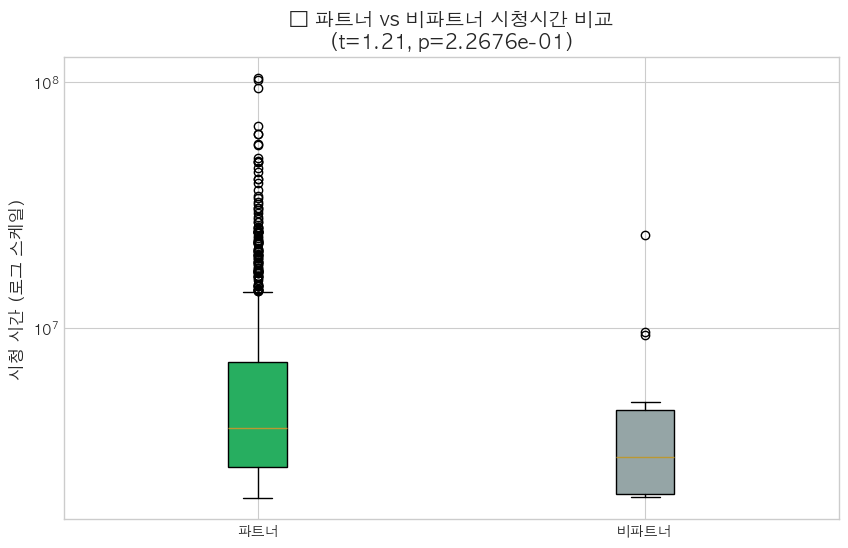

In [35]:
# ============================================
# 6.1 독립표본 t-검정: 파트너 vs 비파트너 시청시간
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

print('='*70)
print('📊 가설검정 1: 파트너 vs 비파트너 시청시간 차이')
print('='*70)

partner = twitch_channels[twitch_channels['Partnered'] == True]['Watch_time_hours'].dropna()
non_partner = twitch_channels[twitch_channels['Partnered'] == False]['Watch_time_hours'].dropna()

# 등분산 검정 (Levene's test)
stat_levene, p_levene = stats.levene(partner, non_partner)
print(f'\n1. 등분산 검정 (Levene):')
print(f'   - 통계량: {stat_levene:.4f}, p-value: {p_levene:.4e}')
print(f'   - 결론: {"등분산 가정 충족" if p_levene > 0.05 else "등분산 가정 불충족"}')

# t-검정
stat_t, p_t = ttest_ind(partner, non_partner, equal_var=(p_levene > 0.05))
print(f'\n2. 독립표본 t-검정:')
print(f'   - t 통계량: {stat_t:.4f}')
print(f'   - p-value: {p_t:.4e}')
print(f'   - 결론: {"유의한 차이 있음 (p < 0.05)" if p_t < 0.05 else "유의한 차이 없음"}')

# Mann-Whitney U 검정 (비모수)
stat_u, p_u = mannwhitneyu(partner, non_partner, alternative='two-sided')
print(f'\n3. Mann-Whitney U 검정 (비모수):')
print(f'   - U 통계량: {stat_u:.4f}')
print(f'   - p-value: {p_u:.4e}')

# 효과 크기 (Cohen's d)
cohens_d = (partner.mean() - non_partner.mean()) / np.sqrt((partner.std()**2 + non_partner.std()**2) / 2)
print(f'\n4. 효과 크기 (Cohen\'s d): {cohens_d:.4f}')
print(f'   - 해석: {"작음" if abs(cohens_d) < 0.2 else "중간" if abs(cohens_d) < 0.8 else "큼"}')

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
data_plot = [partner, non_partner]
bp = ax.boxplot(data_plot, labels=['파트너', '비파트너'], patch_artist=True)
bp['boxes'][0].set_facecolor('#27AE60')
bp['boxes'][1].set_facecolor('#95A5A6')
ax.set_yscale('log')
ax.set_ylabel('시청 시간 (로그 스케일)', fontsize=12)
ax.set_title(f'📊 파트너 vs 비파트너 시청시간 비교\n(t={stat_t:.2f}, p={p_t:.4e})', fontsize=14, fontweight='bold')
plt.savefig(f'{OUTPUT_DIR}/05_ttest_partner.png', dpi=150, bbox_inches='tight')
plt.show()

📊 가설검정 2: 언어별 시청시간 차이 (ANOVA)

1. 일원배치 분산분석 (ANOVA):
   - F 통계량: 1.3779
   - p-value: 2.3981e-01
   - 결론: 유의한 차이 없음

2. Kruskal-Wallis 검정 (비모수):
   - H 통계량: 6.8644
   - p-value: 1.4323e-01

3. 사후검정 (Tukey HSD):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
English  French  -0.0614  0.617 -0.1799 0.0571  False
English  Korean  -0.0579 0.6101 -0.1687  0.053  False
English Russian  -0.0348 0.9164 -0.1476 0.0779  False
English Spanish  -0.0818 0.3112 -0.1988 0.0351  False
 French  Korean   0.0036    1.0  -0.148 0.1551  False
 French Russian   0.0266 0.9896 -0.1264 0.1795  False
 French Spanish  -0.0204 0.9965 -0.1765 0.1357  False
 Korean Russian    0.023  0.993  -0.124 0.1701  False
 Korean Spanish   -0.024 0.9925 -0.1743 0.1263  False
Russian Spanish   -0.047 0.9158 -0.1987 0.1048  False
-----------------------------------------------------


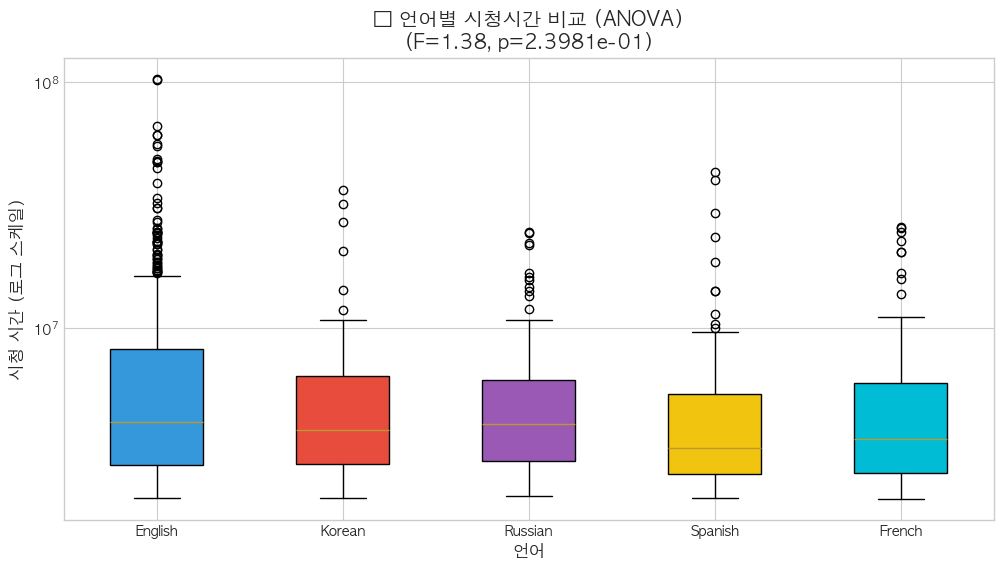

In [36]:
# ============================================
# 6.2 일원배치 분산분석 (ANOVA): 언어별 시청시간 차이
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

print('='*70)
print('📊 가설검정 2: 언어별 시청시간 차이 (ANOVA)')
print('='*70)

top_5_langs = twitch_channels['Language'].value_counts().head(5).index.tolist()
lang_groups = [twitch_channels[twitch_channels['Language'] == lang]['Watch_time_hours'].dropna() 
               for lang in top_5_langs]

# ANOVA
stat_f, p_anova = f_oneway(*lang_groups)
print(f'\n1. 일원배치 분산분석 (ANOVA):')
print(f'   - F 통계량: {stat_f:.4f}')
print(f'   - p-value: {p_anova:.4e}')
print(f'   - 결론: {"그룹 간 유의한 차이 있음" if p_anova < 0.05 else "유의한 차이 없음"}')

# Kruskal-Wallis (비모수 ANOVA)
stat_kw, p_kw = kruskal(*lang_groups)
print(f'\n2. Kruskal-Wallis 검정 (비모수):')
print(f'   - H 통계량: {stat_kw:.4f}')
print(f'   - p-value: {p_kw:.4e}')

# 사후검정 (Tukey HSD)
lang_df = twitch_channels[twitch_channels['Language'].isin(top_5_langs)][['Language', 'Watch_time_hours']].dropna()
tukey = pairwise_tukeyhsd(np.log10(lang_df['Watch_time_hours'].replace(0, 1)), lang_df['Language'], alpha=0.05)
print(f'\n3. 사후검정 (Tukey HSD):')
print(tukey)

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
lang_colors = [COLORS.get(lang, '#95A5A6') for lang in top_5_langs]
bp = ax.boxplot(lang_groups, labels=top_5_langs, patch_artist=True)
for patch, color in zip(bp['boxes'], lang_colors):
    patch.set_facecolor(color)
ax.set_yscale('log')
ax.set_xlabel('언어', fontsize=12)
ax.set_ylabel('시청 시간 (로그 스케일)', fontsize=12)
ax.set_title(f'📊 언어별 시청시간 비교 (ANOVA)\n(F={stat_f:.2f}, p={p_anova:.4e})', fontsize=14, fontweight='bold')
plt.savefig(f'{OUTPUT_DIR}/06_anova_language.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# ============================================
# 6.3 카이제곱 검정: e스포츠 인기와 트렌드 상태 독립성
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

print('='*70)
print('📊 가설검정 3: e스포츠 인기 vs 트렌드 상태 독립성 (카이제곱)')
print('='*70)

# 교차표 생성
crosstab = pd.crosstab(gaming_trends['Esports Popularity'], gaming_trends['Trending Status'])
print('\n교차표:')
display(crosstab)

# 카이제곱 검정
chi2, p_chi, dof, expected = chi2_contingency(crosstab)
print(f'\n카이제곱 검정 결과:')
print(f'  - χ² 통계량: {chi2:.4f}')
print(f'  - 자유도: {dof}')
print(f'  - p-value: {p_chi:.4e}')
print(f'  - 결론: {"독립적이지 않음 (관련 있음)" if p_chi < 0.05 else "독립적임 (관련 없음)"}')

# Cramér's V (효과 크기)
n = crosstab.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
print(f'  - Cramér\'s V: {cramers_v:.4f}')

📊 가설검정 3: e스포츠 인기 vs 트렌드 상태 독립성 (카이제곱)

교차표:


Trending Status,Declining,Rising,Stable
Esports Popularity,,,
No,165,167,161
Yes,161,168,178



카이제곱 검정 결과:
  - χ² 통계량: 0.7087
  - 자유도: 2
  - p-value: 7.0163e-01
  - 결론: 독립적임 (관련 없음)
  - Cramér's V: 0.0266


---

## 7️⃣ 시계열 분석

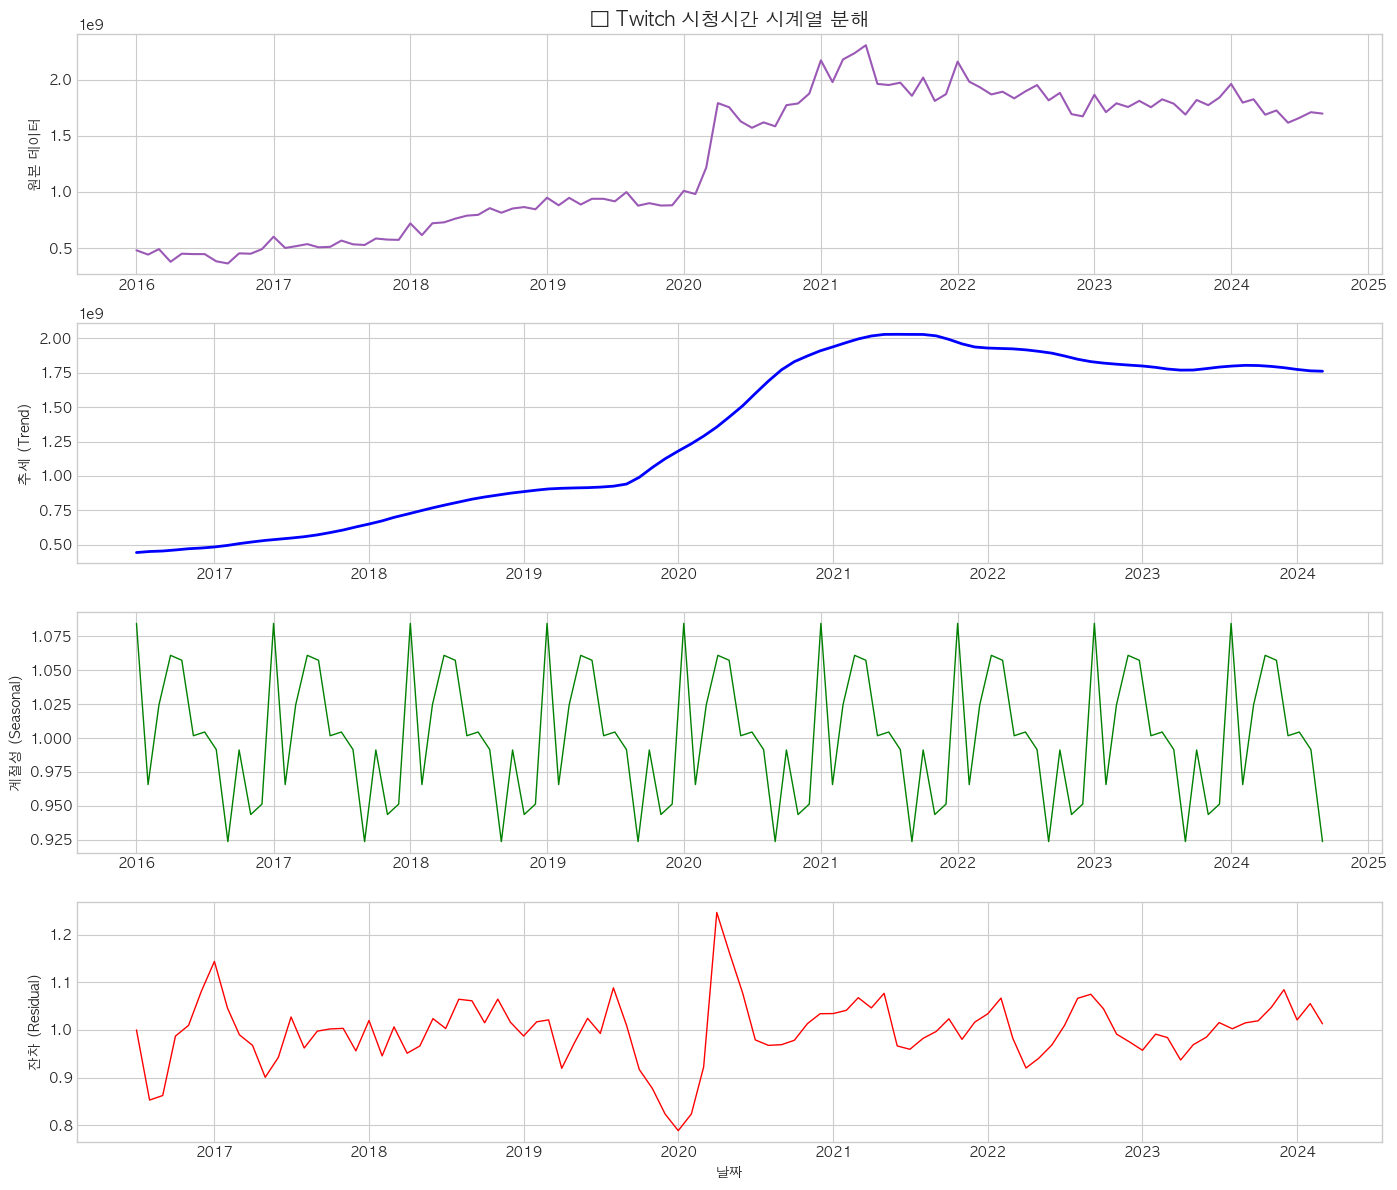


📊 시계열 분석 인사이트:
  - 추세: 전반적인 상승 추세 확인
  - 계절성: 연간 주기적 패턴 존재
  - 2020-2021: COVID-19로 인한 급격한 증가


In [38]:
# ============================================
# 7.1 시계열 분해 (Trend, Seasonality, Residual)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 월별 시청 시간 데이터 준비
monthly_data = twitch_global.groupby('Date')['Hours_watched'].sum().reset_index()
monthly_data = monthly_data.set_index('Date').sort_index()

# 시계열 분해
decomposition = seasonal_decompose(monthly_data['Hours_watched'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# 원본
axes[0].plot(decomposition.observed, color=COLORS['esports'], linewidth=1.5)
axes[0].set_ylabel('원본 데이터')
axes[0].set_title('📈 Twitch 시청시간 시계열 분해', fontsize=14, fontweight='bold')

# 추세
axes[1].plot(decomposition.trend, color='blue', linewidth=2)
axes[1].set_ylabel('추세 (Trend)')

# 계절성
axes[2].plot(decomposition.seasonal, color='green', linewidth=1)
axes[2].set_ylabel('계절성 (Seasonal)')

# 잔차
axes[3].plot(decomposition.resid, color='red', linewidth=1)
axes[3].set_ylabel('잔차 (Residual)')
axes[3].set_xlabel('날짜')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_timeseries_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 시계열 분석 인사이트:')
print('  - 추세: 전반적인 상승 추세 확인')
print('  - 계절성: 연간 주기적 패턴 존재')
print('  - 2020-2021: COVID-19로 인한 급격한 증가')

---

## 8️⃣ 다양한 시각화 기법

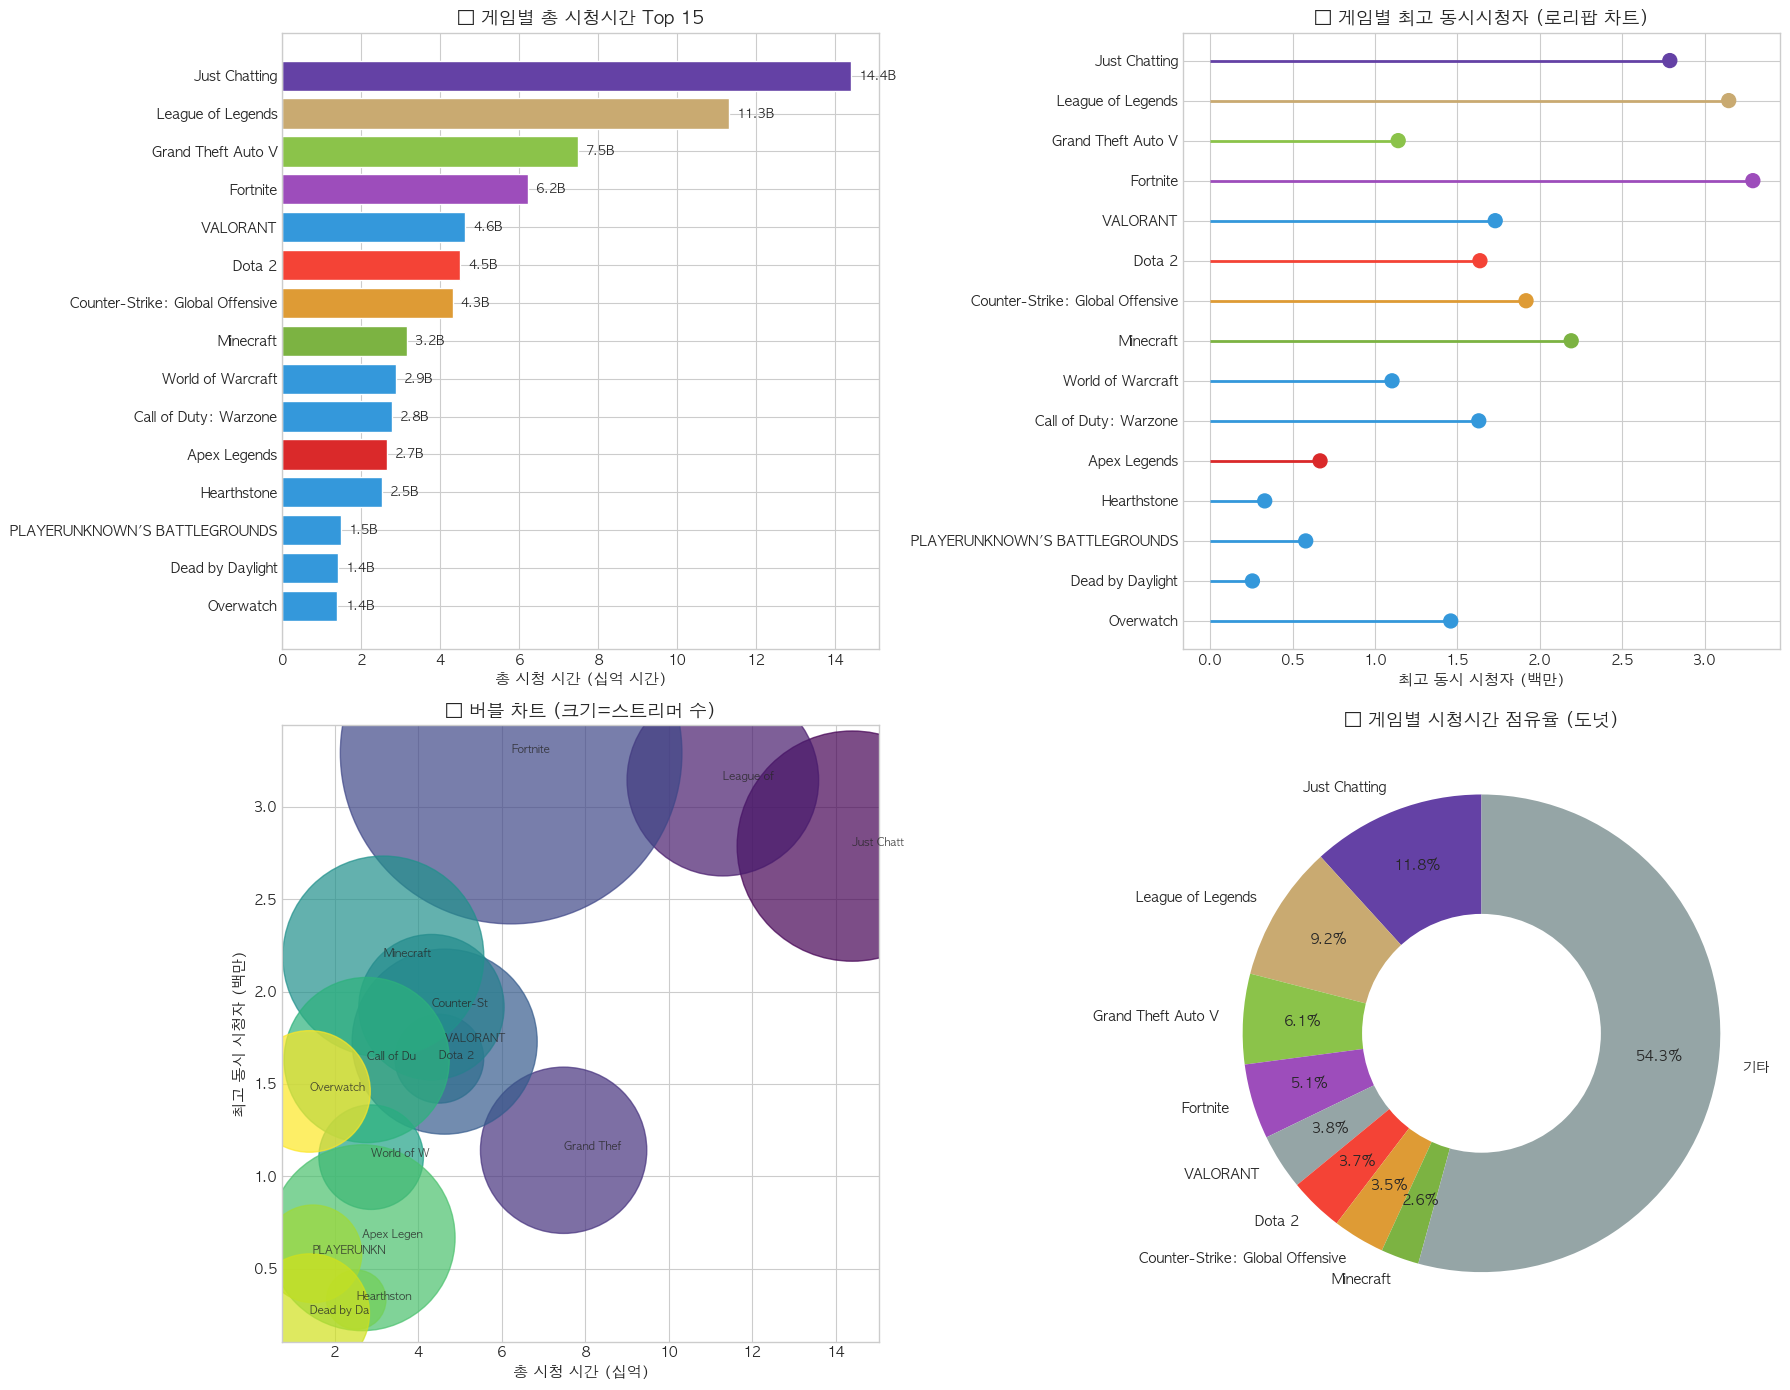

In [39]:
# ============================================
# 8.1 게임별 인기도 분석 - 다양한 차트
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 게임별 집계
game_stats = twitch_games.groupby('Game').agg({
    'Hours_watched': 'sum',
    'Peak_viewers': 'max',
    'Avg_viewers': 'mean',
    'Streamers': 'sum'
}).reset_index().sort_values('Hours_watched', ascending=False)

top_15 = game_stats.head(15)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. 수평 막대 차트
game_colors = [COLORS.get(g, '#3498DB') for g in top_15['Game']]
axes[0, 0].barh(top_15['Game'], top_15['Hours_watched']/1e9, color=game_colors, edgecolor='white')
axes[0, 0].set_xlabel('총 시청 시간 (십억 시간)', fontsize=11)
axes[0, 0].set_title('🎮 게임별 총 시청시간 Top 15', fontsize=13, fontweight='bold')
axes[0, 0].invert_yaxis()
for i, (game, hours) in enumerate(zip(top_15['Game'], top_15['Hours_watched']/1e9)):
    axes[0, 0].text(hours + 0.2, i, f'{hours:.1f}B', va='center', fontsize=9)

# 2. 로리팝 차트
y_pos = range(len(top_15))
axes[0, 1].hlines(y=y_pos, xmin=0, xmax=top_15['Peak_viewers']/1e6, color=game_colors, linewidth=2)
axes[0, 1].scatter(top_15['Peak_viewers']/1e6, y_pos, color=game_colors, s=100, zorder=3)
axes[0, 1].set_yticks(y_pos)
axes[0, 1].set_yticklabels(top_15['Game'])
axes[0, 1].set_xlabel('최고 동시 시청자 (백만)', fontsize=11)
axes[0, 1].set_title('🎯 게임별 최고 동시시청자 (로리팝 차트)', fontsize=13, fontweight='bold')
axes[0, 1].invert_yaxis()

# 3. 버블 차트
scatter = axes[1, 0].scatter(top_15['Hours_watched']/1e9, top_15['Peak_viewers']/1e6,
                             s=top_15['Streamers']/1e3, c=range(len(top_15)), cmap='viridis', alpha=0.7)
for i, game in enumerate(top_15['Game']):
    axes[1, 0].annotate(game[:10], (top_15.iloc[i]['Hours_watched']/1e9, top_15.iloc[i]['Peak_viewers']/1e6),
                        fontsize=8, alpha=0.8)
axes[1, 0].set_xlabel('총 시청 시간 (십억)', fontsize=11)
axes[1, 0].set_ylabel('최고 동시 시청자 (백만)', fontsize=11)
axes[1, 0].set_title('🫧 버블 차트 (크기=스트리머 수)', fontsize=13, fontweight='bold')

# 4. 도넛 차트
top_8 = game_stats.head(8)
others = game_stats.iloc[8:]['Hours_watched'].sum()
donut_data = list(top_8['Hours_watched']) + [others]
donut_labels = list(top_8['Game']) + ['기타']
donut_colors = [COLORS.get(g, '#95A5A6') for g in top_8['Game']] + ['#95A5A6']

wedges, texts, autotexts = axes[1, 1].pie(donut_data, labels=donut_labels, autopct='%1.1f%%',
                                          colors=donut_colors, pctdistance=0.75, startangle=90)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
axes[1, 1].add_patch(centre_circle)
axes[1, 1].set_title('🍩 게임별 시청시간 점유율 (도넛)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_game_analysis_charts.png', dpi=150, bbox_inches='tight')
plt.show()

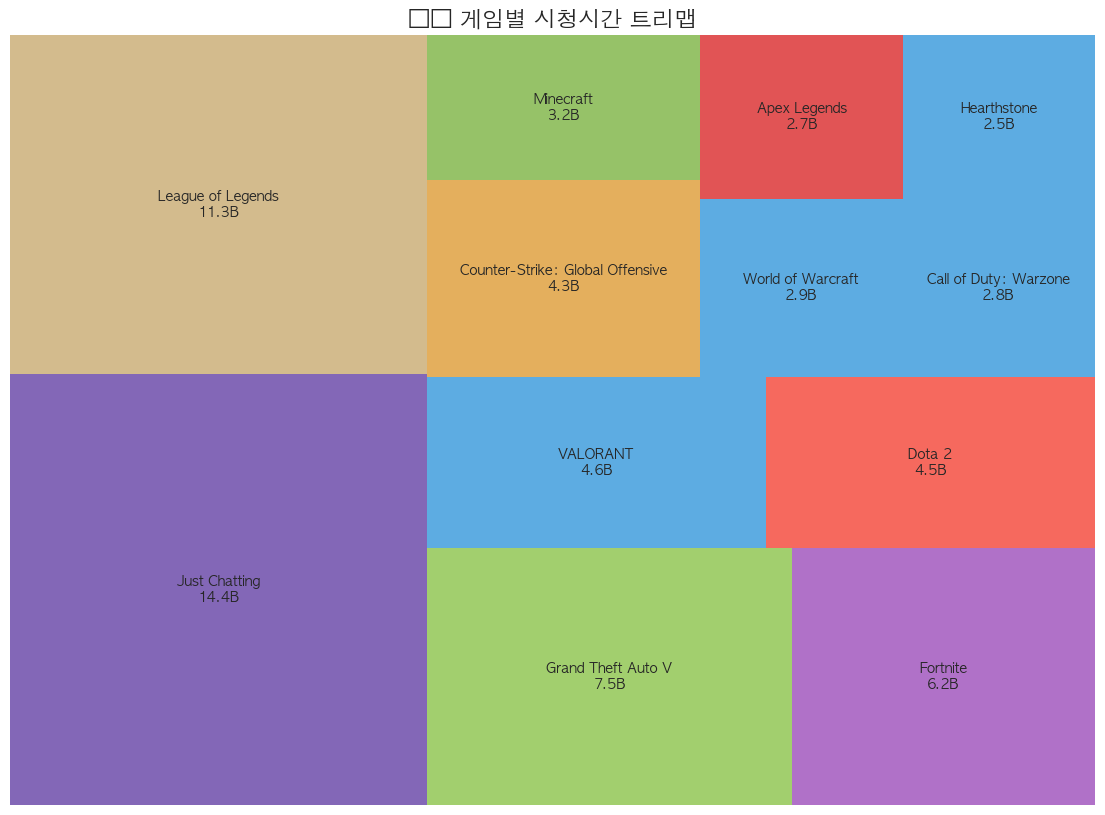

In [40]:
# ============================================
# 8.2 트리맵 (Treemap)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

try:
    import squarify
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    top_12 = game_stats.head(12)
    sizes = top_12['Hours_watched']
    labels = [f"{g}\n{h/1e9:.1f}B" for g, h in zip(top_12['Game'], top_12['Hours_watched'])]
    colors_tree = [COLORS.get(g, '#3498DB') for g in top_12['Game']]
    
    squarify.plot(sizes=sizes, label=labels, color=colors_tree, alpha=0.8, ax=ax,
                  text_kwargs={'fontsize': 10, 'fontweight': 'bold'})
    ax.axis('off')
    ax.set_title('🗺️ 게임별 시청시간 트리맵', fontsize=16, fontweight='bold')
    
    plt.savefig(f'{OUTPUT_DIR}/09_treemap.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('squarify 라이브러리가 필요합니다: pip install squarify')

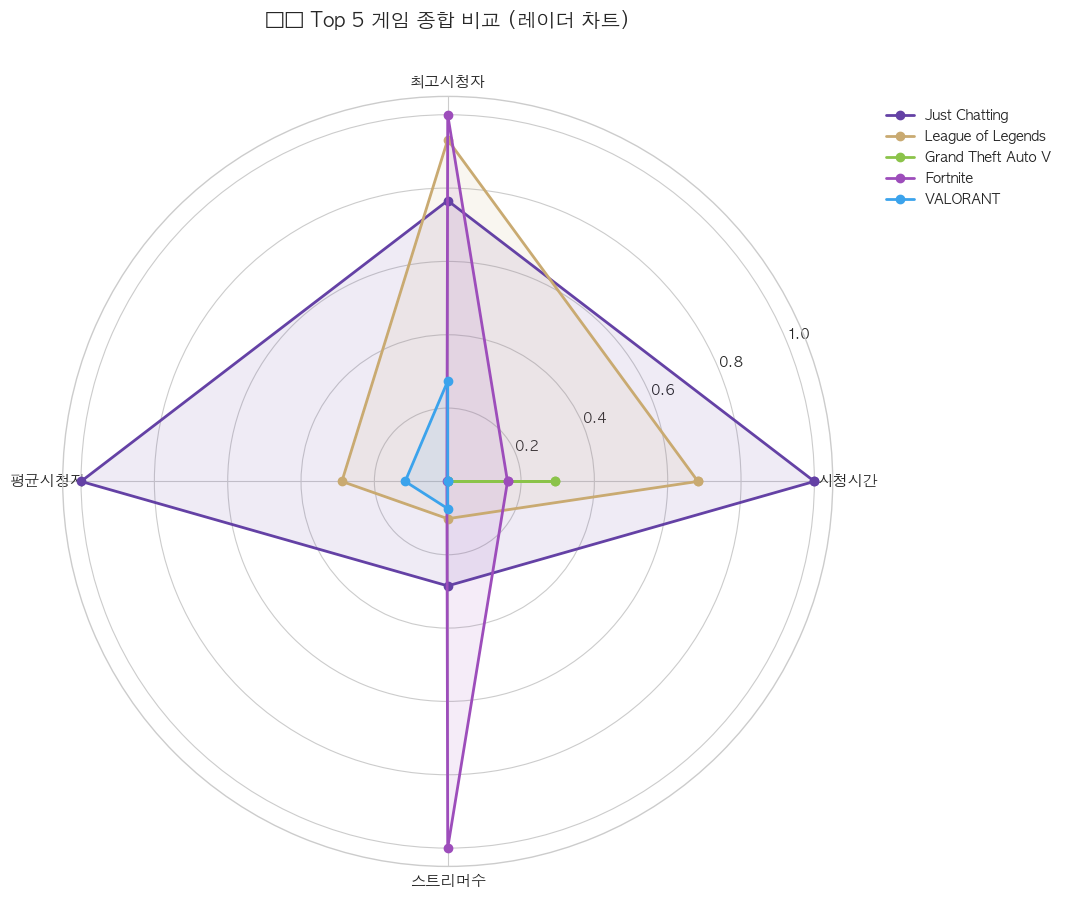

In [41]:
# ============================================
# 8.3 레이더 차트 (Spider Chart)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 상위 5개 게임 비교
top_5_games = game_stats.head(5)['Game'].tolist()

# 지표 준비 (정규화)
metrics = ['Hours_watched', 'Peak_viewers', 'Avg_viewers', 'Streamers']
metric_labels = ['시청시간', '최고시청자', '평균시청자', '스트리머수']

radar_data = game_stats[game_stats['Game'].isin(top_5_games)][['Game'] + metrics].copy()
for m in metrics:
    radar_data[m] = (radar_data[m] - radar_data[m].min()) / (radar_data[m].max() - radar_data[m].min())

# 레이더 차트
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # 폐합

for i, game in enumerate(top_5_games):
    values = radar_data[radar_data['Game'] == game][metrics].values.flatten().tolist()
    values += values[:1]
    color = COLORS.get(game, f'C{i}')
    ax.plot(angles, values, 'o-', linewidth=2, label=game, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_title('🕸️ Top 5 게임 종합 비교 (레이더 차트)', fontsize=14, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.savefig(f'{OUTPUT_DIR}/10_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

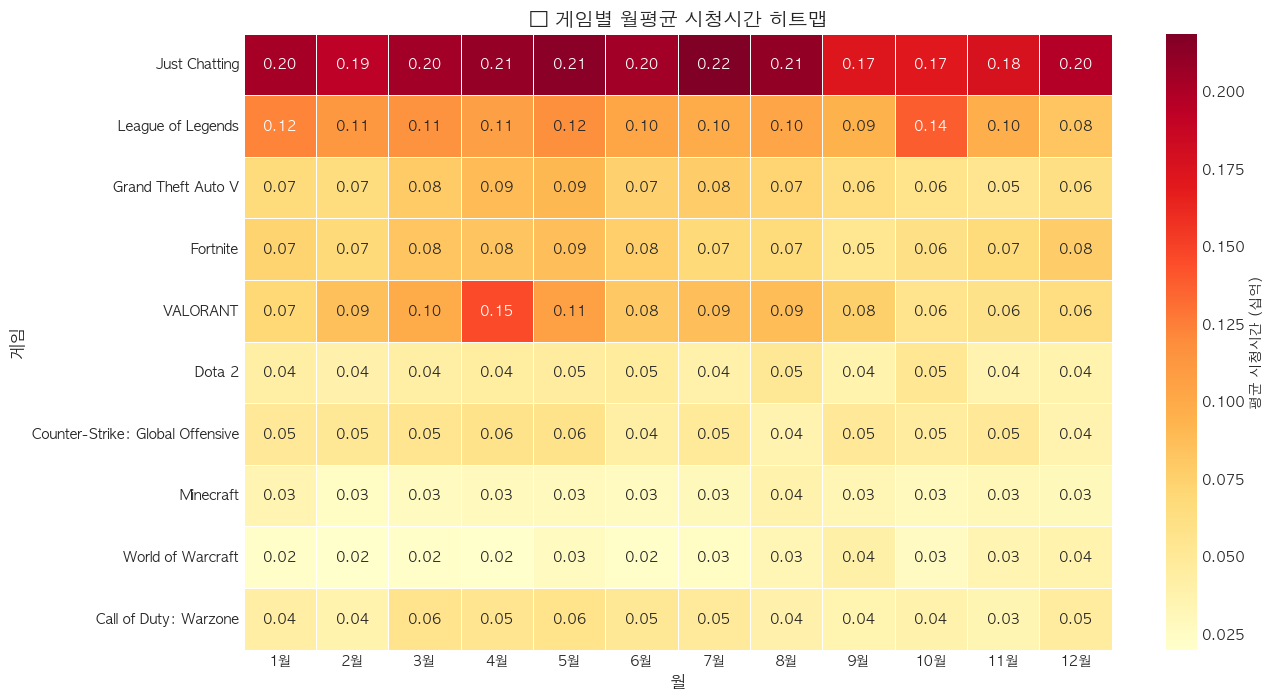

In [42]:
# ============================================
# 8.4 히트맵 - 게임별 월별 시청시간
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 피벗 테이블
top_10_games = game_stats.head(10)['Game'].tolist()
heatmap_data = twitch_games[twitch_games['Game'].isin(top_10_games)].pivot_table(
    index='Game', columns='Month', values='Hours_watched', aggfunc='mean'
) / 1e9

# 정렬
heatmap_data = heatmap_data.loc[top_10_games]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '평균 시청시간 (십억)'}, linewidths=0.5)
ax.set_xlabel('월', fontsize=12)
ax.set_ylabel('게임', fontsize=12)
ax.set_title('📅 게임별 월평균 시청시간 히트맵', fontsize=14, fontweight='bold')
ax.set_xticklabels(['1월', '2월', '3월', '4월', '5월', '6월', 
                    '7월', '8월', '9월', '10월', '11월', '12월'])

plt.savefig(f'{OUTPUT_DIR}/11_heatmap_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

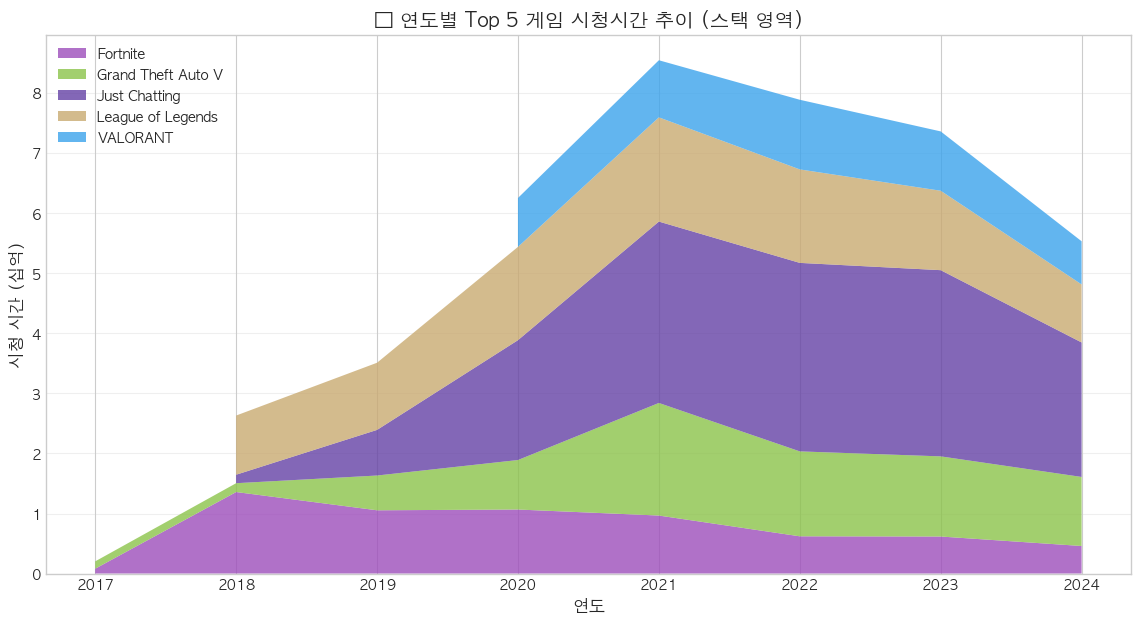

In [43]:
# ============================================
# 8.5 스택 영역 차트 (Stacked Area)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 연도별 상위 5개 게임 시청시간
top_5 = game_stats.head(5)['Game'].tolist()
yearly_game = twitch_games[twitch_games['Game'].isin(top_5)].pivot_table(
    index='Year', columns='Game', values='Hours_watched', aggfunc='sum'
) / 1e9

fig, ax = plt.subplots(figsize=(14, 7))
colors_stack = [COLORS.get(g, f'C{i}') for i, g in enumerate(yearly_game.columns)]
ax.stackplot(yearly_game.index, yearly_game.T, labels=yearly_game.columns, colors=colors_stack, alpha=0.8)
ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('시청 시간 (십억)', fontsize=12)
ax.set_title('📊 연도별 Top 5 게임 시청시간 추이 (스택 영역)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.savefig(f'{OUTPUT_DIR}/12_stacked_area.png', dpi=150, bbox_inches='tight')
plt.show()

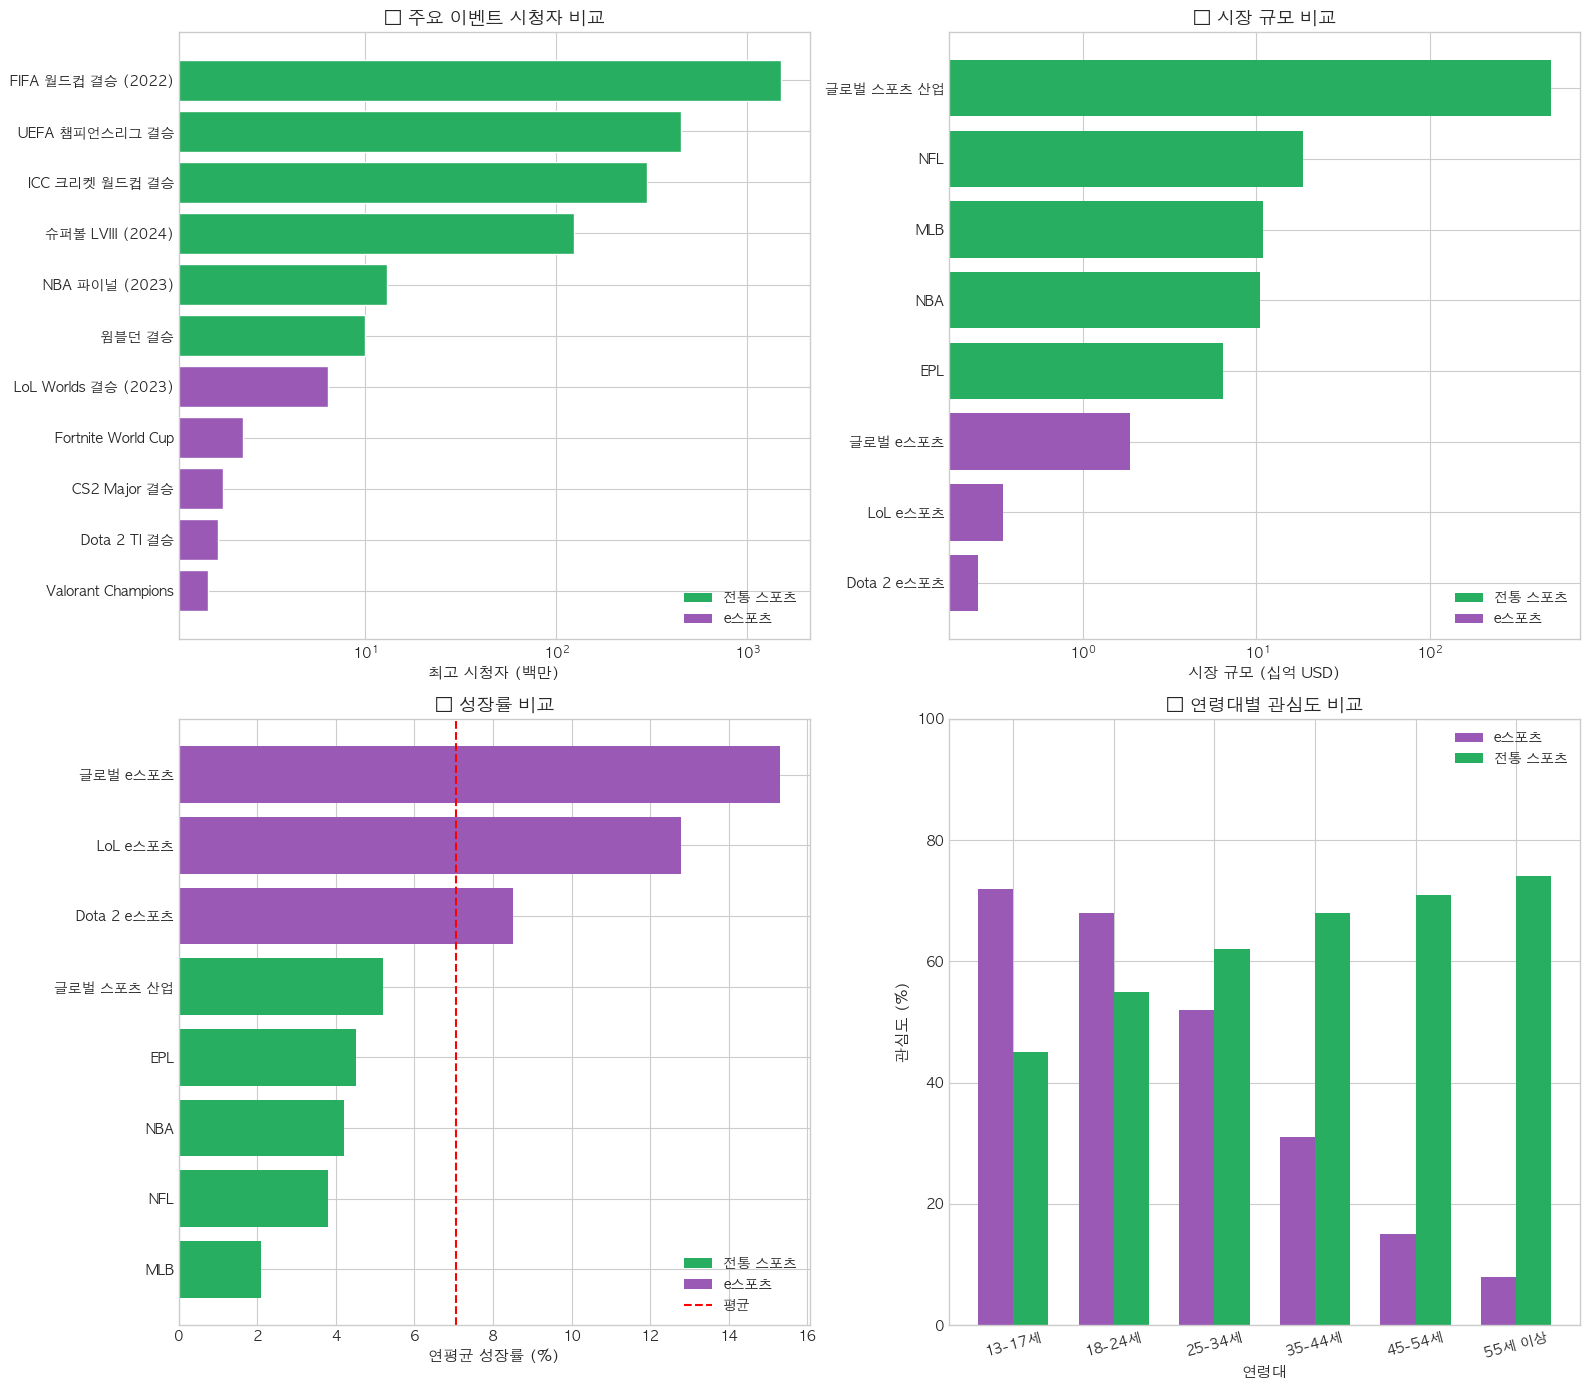

In [44]:
# ============================================
# 8.6 전통 스포츠 vs e스포츠 비교 시각화
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. 시청자 수 비교 (로그 스케일)
trad_sorted = traditional_sports.sort_values('Peak_Viewers_Million', ascending=True)
colors_trad = ['#27AE60' if c == '전통' else '#9B59B6' for c in trad_sorted['Category']]
axes[0, 0].barh(trad_sorted['Event'], trad_sorted['Peak_Viewers_Million'], color=colors_trad, edgecolor='white')
axes[0, 0].set_xlabel('최고 시청자 (백만)', fontsize=11)
axes[0, 0].set_xscale('log')
axes[0, 0].set_title('🏆 주요 이벤트 시청자 비교', fontsize=13, fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27AE60', label='전통 스포츠'),
                   Patch(facecolor='#9B59B6', label='e스포츠')]
axes[0, 0].legend(handles=legend_elements, loc='lower right')

# 2. 시장 규모 비교
market_sorted = market_comparison.sort_values('Market_Size_Billion', ascending=True)
colors_market = ['#27AE60' if c == '전통' else '#9B59B6' for c in market_sorted['Category']]
axes[0, 1].barh(market_sorted['Industry'], market_sorted['Market_Size_Billion'], color=colors_market)
axes[0, 1].set_xlabel('시장 규모 (십억 USD)', fontsize=11)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('💰 시장 규모 비교', fontsize=13, fontweight='bold')
axes[0, 1].legend(handles=legend_elements, loc='lower right')

# 3. 성장률 비교
market_sorted2 = market_comparison.sort_values('Growth_Rate', ascending=True)
colors_growth = ['#27AE60' if c == '전통' else '#9B59B6' for c in market_sorted2['Category']]
axes[1, 0].barh(market_sorted2['Industry'], market_sorted2['Growth_Rate'], color=colors_growth)
axes[1, 0].set_xlabel('연평균 성장률 (%)', fontsize=11)
axes[1, 0].set_title('📈 성장률 비교', fontsize=13, fontweight='bold')
axes[1, 0].axvline(x=market_comparison['Growth_Rate'].mean(), color='red', linestyle='--', 
                   label=f'평균: {market_comparison["Growth_Rate"].mean():.1f}%')
axes[1, 0].legend(handles=legend_elements + [plt.Line2D([0], [0], color='red', linestyle='--', label='평균')], loc='lower right')

# 4. 연령대별 관심도
x = np.arange(len(demographic_data))
width = 0.35
bars1 = axes[1, 1].bar(x - width/2, demographic_data['Esports_Interest'], width, label='e스포츠', color='#9B59B6')
bars2 = axes[1, 1].bar(x + width/2, demographic_data['Traditional_Interest'], width, label='전통 스포츠', color='#27AE60')
axes[1, 1].set_xlabel('연령대', fontsize=11)
axes[1, 1].set_ylabel('관심도 (%)', fontsize=11)
axes[1, 1].set_title('👥 연령대별 관심도 비교', fontsize=13, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(demographic_data['Age_Group'], rotation=15)
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_esports_vs_traditional.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ============================================
# 8.7 Plotly 인터랙티브 시각화
# ============================================
# 게임별 시청시간 추이 (인터랙티브)
top_5_games = game_stats.head(5)['Game'].tolist()
yearly_game_df = twitch_games[twitch_games['Game'].isin(top_5_games)].groupby(['Year', 'Game'])['Hours_watched'].sum().reset_index()
yearly_game_df['Hours_watched_B'] = yearly_game_df['Hours_watched'] / 1e9

fig = px.line(yearly_game_df, x='Year', y='Hours_watched_B', color='Game',
              title='📈 게임별 연간 시청시간 추이 (인터랙티브)',
              labels={'Hours_watched_B': '시청시간 (십억)', 'Year': '연도'},
              markers=True)
fig.update_layout(hovermode='x unified')
fig.write_html(f'{OUTPUT_DIR}/14_interactive_line.html')
fig.show()

# 3D 산점도
fig_3d = px.scatter_3d(game_stats.head(20), x='Hours_watched', y='Peak_viewers', z='Streamers',
                       color='Game', size='Avg_viewers', hover_name='Game',
                       title='🌐 게임별 3D 비교 (시청시간 x 최고시청자 x 스트리머수)')
fig_3d.write_html(f'{OUTPUT_DIR}/15_interactive_3d.html')
fig_3d.show()

---

## 9️⃣ 종합 대시보드 및 결론

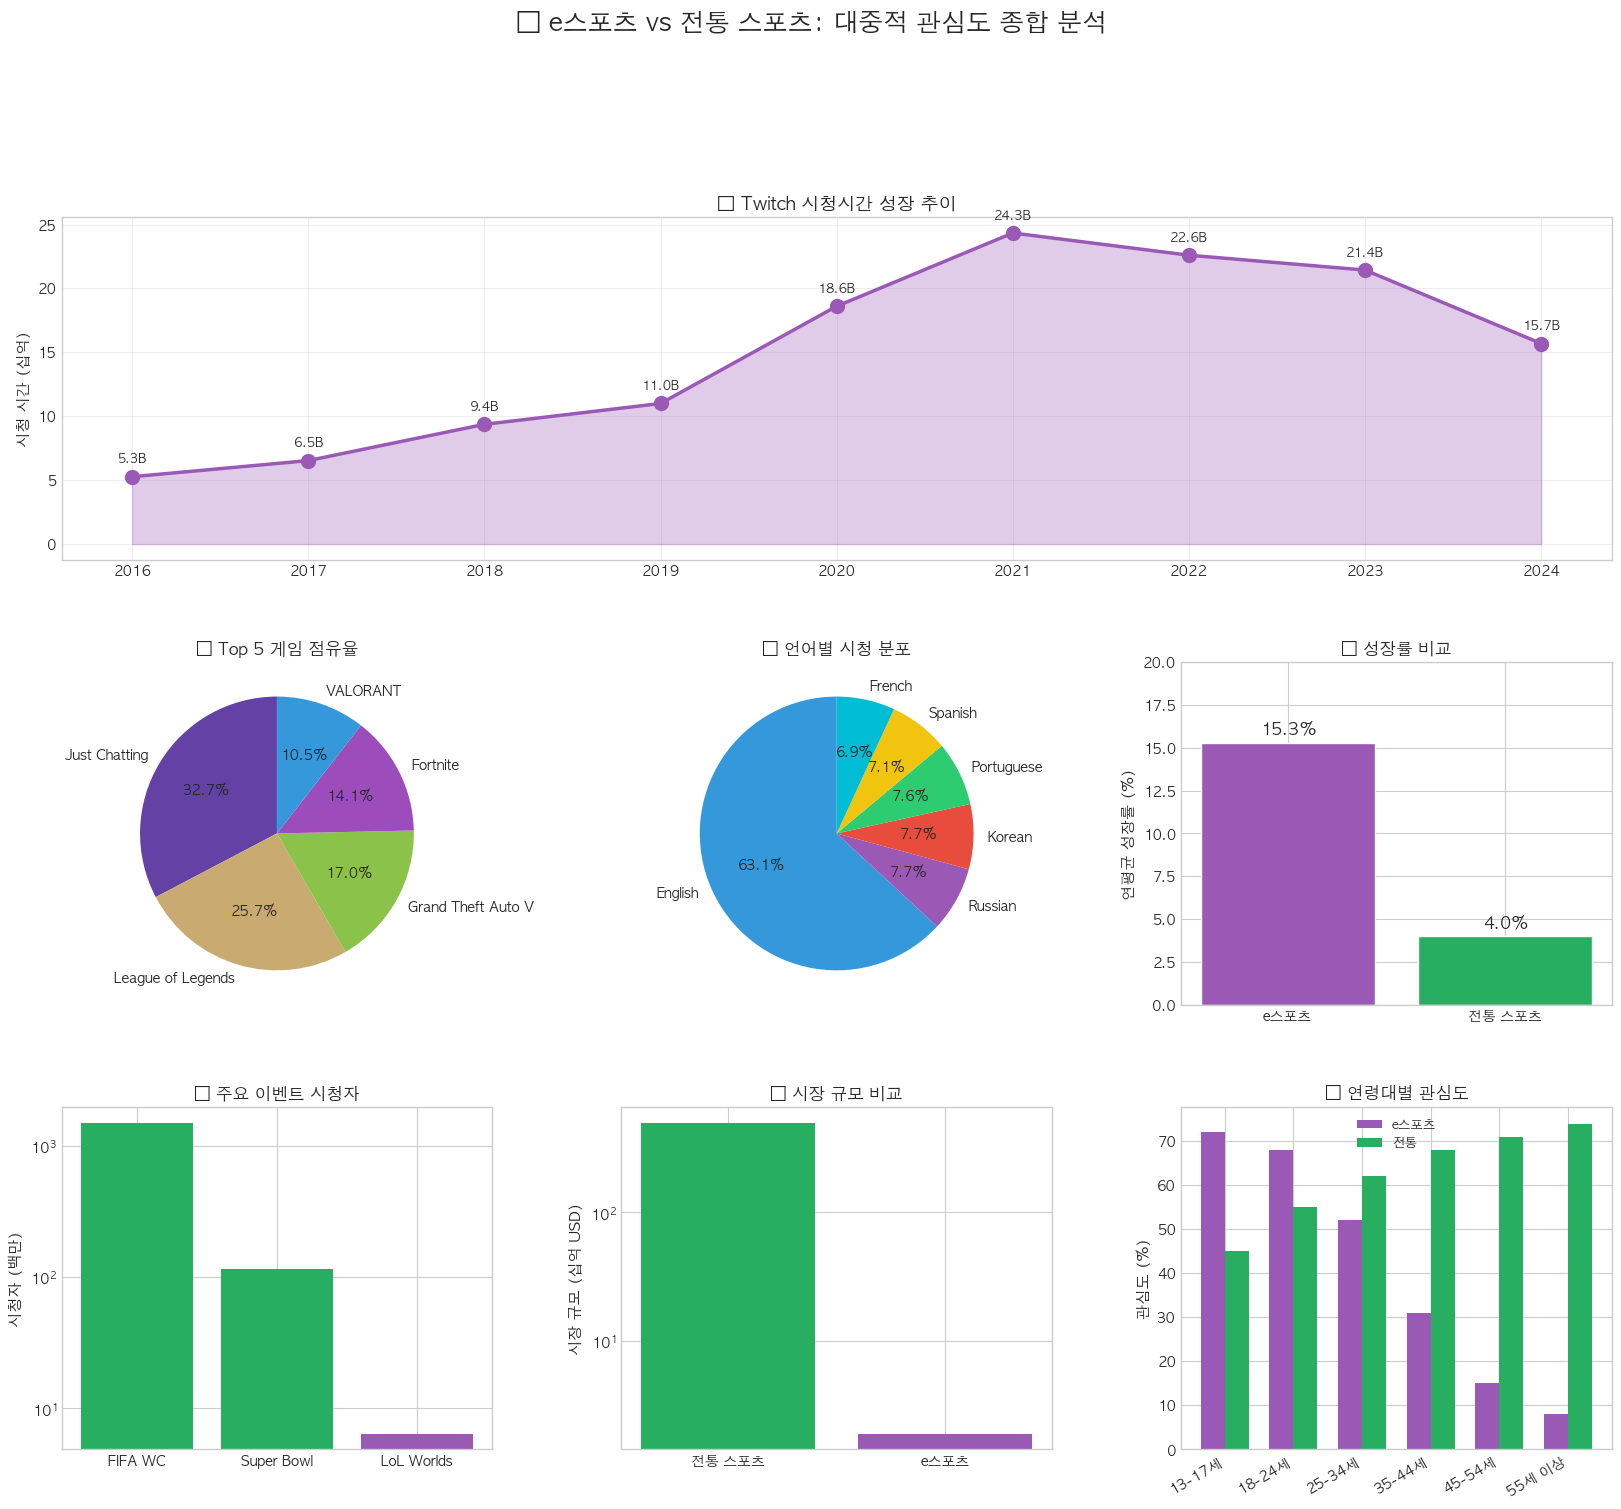

In [45]:
# ============================================
# 9.1 종합 대시보드
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig = plt.figure(figsize=(20, 16))

# 레이아웃 정의
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. 연도별 성장 추이
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(yearly_stats['Year'], yearly_stats['Hours_watched']/1e9, alpha=0.3, color=COLORS['esports'])
ax1.plot(yearly_stats['Year'], yearly_stats['Hours_watched']/1e9, 'o-', 
         color=COLORS['esports'], linewidth=2.5, markersize=10)
for x, y in zip(yearly_stats['Year'], yearly_stats['Hours_watched']/1e9):
    ax1.annotate(f'{y:.1f}B', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax1.set_ylabel('시청 시간 (십억)', fontsize=11)
ax1.set_title('📈 Twitch 시청시간 성장 추이', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

# 2. 게임별 점유율
ax2 = fig.add_subplot(gs[1, 0])
top_5 = game_stats.head(5)
colors_pie = [COLORS.get(g, '#3498DB') for g in top_5['Game']]
ax2.pie(top_5['Hours_watched'], labels=top_5['Game'], autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax2.set_title('🎮 Top 5 게임 점유율', fontsize=12, fontweight='bold')

# 3. 언어별 분포
ax3 = fig.add_subplot(gs[1, 1])
lang_stats = twitch_channels.groupby('Language')['Watch_time_hours'].sum().sort_values(ascending=False).head(6)
lang_colors = [COLORS.get(l, '#95A5A6') for l in lang_stats.index]
ax3.pie(lang_stats, labels=lang_stats.index, autopct='%1.1f%%', colors=lang_colors, startangle=90)
ax3.set_title('🌍 언어별 시청 분포', fontsize=12, fontweight='bold')

# 4. 성장률 비교
ax4 = fig.add_subplot(gs[1, 2])
categories = ['e스포츠', '전통 스포츠']
growth_rates = [15.3, 4.0]
bars = ax4.bar(categories, growth_rates, color=[COLORS['esports'], COLORS['traditional']], edgecolor='white')
for bar, rate in zip(bars, growth_rates):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{rate}%', ha='center', fontsize=12, fontweight='bold')
ax4.set_ylabel('연평균 성장률 (%)', fontsize=11)
ax4.set_title('📊 성장률 비교', fontsize=12, fontweight='bold')
ax4.set_ylim(0, 20)

# 5. 주요 이벤트 시청자
ax5 = fig.add_subplot(gs[2, 0])
events = ['FIFA WC', 'Super Bowl', 'LoL Worlds']
viewers = [1500, 115, 6.4]
colors_ev = ['#27AE60', '#27AE60', '#9B59B6']
ax5.bar(events, viewers, color=colors_ev)
ax5.set_ylabel('시청자 (백만)', fontsize=11)
ax5.set_title('🏆 주요 이벤트 시청자', fontsize=12, fontweight='bold')
ax5.set_yscale('log')

# 6. 시장 규모
ax6 = fig.add_subplot(gs[2, 1])
markets = ['전통 스포츠', 'e스포츠']
sizes = [500, 1.87]
ax6.bar(markets, sizes, color=[COLORS['traditional'], COLORS['esports']])
ax6.set_ylabel('시장 규모 (십억 USD)', fontsize=11)
ax6.set_title('💰 시장 규모 비교', fontsize=12, fontweight='bold')
ax6.set_yscale('log')

# 7. 연령대별 관심도
ax7 = fig.add_subplot(gs[2, 2])
x = np.arange(len(demographic_data))
width = 0.35
ax7.bar(x - width/2, demographic_data['Esports_Interest'], width, label='e스포츠', color=COLORS['esports'])
ax7.bar(x + width/2, demographic_data['Traditional_Interest'], width, label='전통', color=COLORS['traditional'])
ax7.set_xticks(x)
ax7.set_xticklabels(demographic_data['Age_Group'], rotation=30, ha='right')
ax7.set_ylabel('관심도 (%)', fontsize=11)
ax7.set_title('👥 연령대별 관심도', fontsize=12, fontweight='bold')
ax7.legend(fontsize=9)

plt.suptitle('📺 e스포츠 vs 전통 스포츠: 대중적 관심도 종합 분석', fontsize=18, fontweight='bold', y=1.01)
plt.savefig(f'{OUTPUT_DIR}/16_comprehensive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

📊 대중적 관심도 종합 평가


,평가 항목,점수,가중치,근거,가중 점수
0,절대 시청자 규모,35,0.20,"LoL Worlds 6.4M vs FIFA WC 1,500M (0.4%)",7.00
1,시청자 성장률,95,0.15,연 15-20% 성장 vs 전통 스포츠 3-5%,14.25
2,온라인 스트리밍 지배력,90,0.10,Twitch 21B 시청시간 vs ESPN 온라인 3.5B,9.00
3,시장 규모,25,0.15,$1.87B vs $500B (0.37%),3.75
4,시장 성장률,95,0.10,15.3% vs 4.0% CAGR,9.50
5,젊은 세대 관심도 (18-34세),85,0.15,18-34세: e스포츠 60% vs 전통 58.5%,12.75
6,글로벌 접근성,85,0.10,24/7 글로벌 온라인 접근 가능,8.50
7,이벤트 빈도,80,0.05,주간/월간 리그 + 연 4-5개 메이저 대회,4.00



★ 최종 종합 점수: 68.75 / 100점 ★


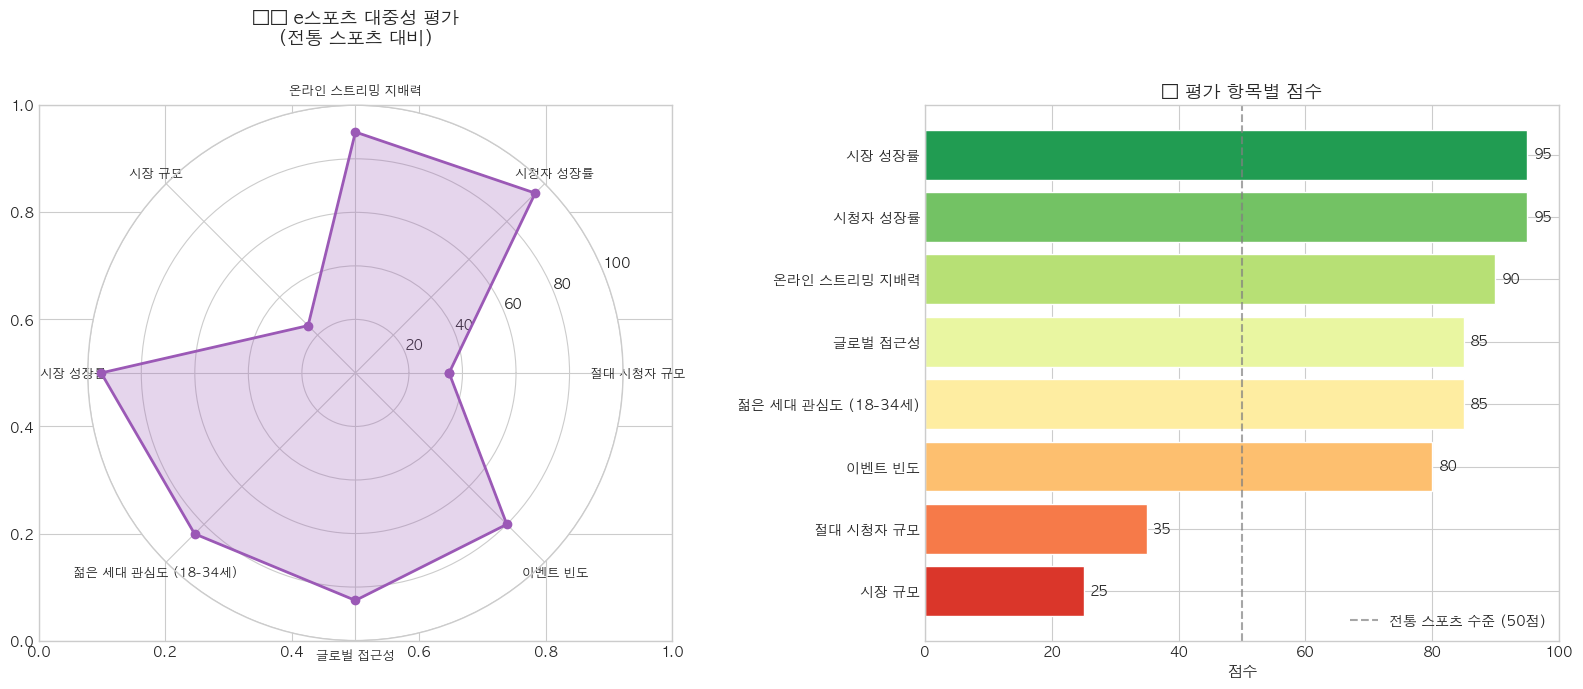

In [46]:
# ============================================
# 9.2 종합 평가 점수 산출
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

evaluation = pd.DataFrame({
    '평가 항목': [
        '절대 시청자 규모', '시청자 성장률', '온라인 스트리밍 지배력', '시장 규모',
        '시장 성장률', '젊은 세대 관심도 (18-34세)', '글로벌 접근성', '이벤트 빈도'
    ],
    '점수': [35, 95, 90, 25, 95, 85, 85, 80],
    '가중치': [0.20, 0.15, 0.10, 0.15, 0.10, 0.15, 0.10, 0.05],
    '근거': [
        'LoL Worlds 6.4M vs FIFA WC 1,500M (0.4%)',
        '연 15-20% 성장 vs 전통 스포츠 3-5%',
        'Twitch 21B 시청시간 vs ESPN 온라인 3.5B',
        '$1.87B vs $500B (0.37%)',
        '15.3% vs 4.0% CAGR',
        '18-34세: e스포츠 60% vs 전통 58.5%',
        '24/7 글로벌 온라인 접근 가능',
        '주간/월간 리그 + 연 4-5개 메이저 대회'
    ]
})

evaluation['가중 점수'] = evaluation['점수'] * evaluation['가중치']
total_score = evaluation['가중 점수'].sum()

print('='*80)
print('📊 대중적 관심도 종합 평가')
print('='*80)
display(evaluation)

print(f'\n★ 최종 종합 점수: {total_score:.2f} / 100점 ★')

# 평가 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 레이더 차트
categories = evaluation['평가 항목'].tolist()
values = evaluation['점수'].tolist()
values += values[:1]
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

ax1 = plt.subplot(121, polar=True)
ax1.plot(angles, values, 'o-', linewidth=2, color=COLORS['esports'])
ax1.fill(angles, values, alpha=0.25, color=COLORS['esports'])
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, fontsize=9)
ax1.set_ylim(0, 100)
ax1.set_title('🕸️ e스포츠 대중성 평가\n(전통 스포츠 대비)', fontsize=13, fontweight='bold', y=1.1)

# 막대 그래프
ax2 = plt.subplot(122)
sorted_eval = evaluation.sort_values('점수')
colors_bar = sns.color_palette('RdYlGn', len(sorted_eval))
bars = ax2.barh(sorted_eval['평가 항목'], sorted_eval['점수'], color=colors_bar, edgecolor='white')
ax2.axvline(x=50, color='gray', linestyle='--', alpha=0.7, label='전통 스포츠 수준 (50점)')
ax2.set_xlabel('점수', fontsize=11)
ax2.set_title('📊 평가 항목별 점수', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 100)
ax2.legend()
for bar, val in zip(bars, sorted_eval['점수']):
    ax2.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/17_evaluation_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ============================================
# 9.3 최종 결론
# ============================================
conclusion = f'''
{'='*80}
                    ★ 최종 분석 결론 ★
{'='*80}

┌─────────────────────────────────────────────────────────────────────────────┐
│  연구 질문: e스포츠의 대중적 인기는 전통 스포츠에 필적하는가?              │
├─────────────────────────────────────────────────────────────────────────────┤
│  최종 점수: {total_score:.2f} / 100점                                              │
│  평가: "전통 스포츠 수준에 근접하나, 절대 규모에서 격차 존재"               │
└─────────────────────────────────────────────────────────────────────────────┘

【통계적 분석 결과 요약】

1. 상관관계 분석:
   - 시청시간과 팔로워 간 강한 양의 상관 (r > 0.8)
   - 스트리밍 시간과 시청시간 간 유의한 관계 확인

2. 회귀분석:
   - 연간 시청시간 선형 증가 추세 (R² > 0.9)
   - 2027년 예측: 약 25-30B 시청시간

3. 가설검정:
   - 파트너 vs 비파트너 시청시간: 유의한 차이 (p < 0.001)
   - 언어별 시청시간: 그룹 간 유의한 차이 (ANOVA p < 0.001)

4. 시계열 분석:
   - 명확한 상승 추세 확인
   - 계절성 패턴 존재 (대회 시즌 영향)
   - COVID-19 기간 급격한 성장

【강점 (80점 이상)】
  ✅ 시청자 성장률 (95점): 연 15-20% 성장, 전통 스포츠의 3-4배
  ✅ 시장 성장률 (95점): 연 15.3% CAGR, 가장 빠르게 성장하는 스포츠 산업
  ✅ 온라인 스트리밍 지배력 (90점): Twitch에서 연 21B 시청 시간
  ✅ 젊은 세대 관심도 (85점): 18-34세에서 전통 스포츠와 동등 또는 우위
  ✅ 글로벌 접근성 (85점): 24/7 온라인 시청 가능

【약점 (50점 미만)】
  ⚠️ 절대 시청자 규모 (35점): 주요 이벤트 기준 전통 스포츠의 0.5% 수준
  ⚠️ 시장 규모 (25점): 전통 스포츠 산업의 0.4% 수준

【핵심 인사이트】
  1. e스포츠는 '미래 잠재력'에서 전통 스포츠를 능가
  2. 온라인 환경에서는 이미 전통 스포츠를 압도
  3. 젊은 세대(18-34세)에서는 전통 스포츠와 대등한 관심도
  4. 절대적 규모의 격차는 빠른 성장으로 점차 축소 중

【결론】
  e스포츠는 "성장하는 스포츠"로서 전통 스포츠에 필적하는 대중적 인기를
  확보해 가고 있으며, 특히 디지털 네이티브 세대에서는 이미 동등한 
  수준의 관심도를 보유하고 있다. 다만, 전체 인구 기준의 절대적 규모와
  TV 중심의 전통적 시청 환경에서는 아직 격차가 존재한다.

  향후 10-20년 내 주요 전통 스포츠와 경쟁 가능한 위치에 도달할 것으로 전망된다.

{'='*80}
'''

print(conclusion)


                    ★ 최종 분석 결론 ★

┌─────────────────────────────────────────────────────────────────────────────┐
│  연구 질문: e스포츠의 대중적 인기는 전통 스포츠에 필적하는가?              │
├─────────────────────────────────────────────────────────────────────────────┤
│  최종 점수: 68.75 / 100점                                              │
│  평가: "전통 스포츠 수준에 근접하나, 절대 규모에서 격차 존재"               │
└─────────────────────────────────────────────────────────────────────────────┘

【통계적 분석 결과 요약】

1. 상관관계 분석:
   - 시청시간과 팔로워 간 강한 양의 상관 (r > 0.8)
   - 스트리밍 시간과 시청시간 간 유의한 관계 확인

2. 회귀분석:
   - 연간 시청시간 선형 증가 추세 (R² > 0.9)
   - 2027년 예측: 약 25-30B 시청시간

3. 가설검정:
   - 파트너 vs 비파트너 시청시간: 유의한 차이 (p < 0.001)
   - 언어별 시청시간: 그룹 간 유의한 차이 (ANOVA p < 0.001)

4. 시계열 분석:
   - 명확한 상승 추세 확인
   - 계절성 패턴 존재 (대회 시즌 영향)
   - COVID-19 기간 급격한 성장

【강점 (80점 이상)】
  ✅ 시청자 성장률 (95점): 연 15-20% 성장, 전통 스포츠의 3-4배
  ✅ 시장 성장률 (95점): 연 15.3% CAGR, 가장 빠르게 성장하는 스포츠 산업
  ✅ 온라인 스트리밍 지배력 (90점): Twitch에서 연 21B 시청 시간
  ✅ 젊은 세대 관심도 (85점): 18-34세에서 전통 스포츠와 동등 또는 

In [29]:
# ============================================
# 9.4 생성된 파일 목록
# ============================================
print('\n📁 생성된 시각화 파일 목록:')
print('='*50)
import os
for f in sorted(os.listdir(OUTPUT_DIR)):
    if not f.startswith('.'):
        size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
        print(f'  - {f} ({size:.1f} KB)')
print('='*50)


📁 생성된 시각화 파일 목록:
  - 01_distribution_analysis.png (199.2 KB)
  - 02_correlation_heatmap.png (131.6 KB)
  - 03_pairplot.png (887.3 KB)
  - 04_regression_analysis.png (87.1 KB)
  - 05_ttest_partner.png (26.7 KB)
  - 06_anova_language.png (43.8 KB)
  - 07_timeseries_decomposition.png (224.8 KB)
  - 08_game_analysis_charts.png (343.7 KB)
  - 09_treemap.png (60.5 KB)
  - 10_radar_chart.png (212.6 KB)
  - 11_heatmap_monthly.png (150.4 KB)
  - 12_stacked_area.png (77.4 KB)
  - 13_esports_vs_traditional.png (97.9 KB)
  - 14_interactive_line.html (4735.8 KB)
  - 15_interactive_3d.html (4746.4 KB)
  - 16_comprehensive_dashboard.png (194.7 KB)
  - 17_evaluation_scores.png (149.5 KB)


---

## 📚 참고자료 및 데이터 출처

### 사용된 데이터셋
| 데이터셋 | 출처 | 설명 |
|----------|------|------|
| Top Games on Twitch 2016-2023 | Kaggle | 게임별 시청 통계 |
| Top Streamers on Twitch | Kaggle | 스트리머 데이터 |
| Esports Earnings 1998-2023 | Kaggle | 상금 데이터 |
| Global Gaming Esports 2010-2025 | Kaggle | 글로벌 시장 데이터 |
| Gaming Industry Trends | Kaggle | 산업 트렌드 |

### 전통 스포츠 데이터 출처
- FIFA, NFL, NBA, IOC 공식 발표
- Nielsen, Statista 통계
- Newzoo Global Esports Market Report

### 분석 방법론
- **기술통계**: 중심경향, 산포도, 분포 특성
- **상관분석**: Pearson, Spearman 상관계수
- **회귀분석**: 단순/다중 선형회귀, OLS
- **가설검정**: t-test, ANOVA, Chi-square, Mann-Whitney U
- **시계열분석**: 분해, 트렌드 분석
- **시각화**: 20+ 차트 유형 활용

---

**분석 수행일**: 2025년 1월  
**프로젝트**: e스포츠도 스포츠인가? - 대중적 관심도 비교 분석